# EDA
### Preparación y comprensión
1. Importar librerías
2. Carga de datos
3. Información general
4. Análisis de valores faltantes
5. Extracción de provincias
6. Identificación de tanques
7. Tipar variables
8. Tratamiento de variables numéricas
9. Estadísticas descriptivas - variables numéricas
10. Análisis de columnas categóricas
11. Distribuciones de variables principales
12. Detección de outliers
13. Análisis de correlación
14. Distribución de variables principales

### DATA VISUALIZATION

- SECCIÓN 1: ANÁLISIS DE NIVEL DE AGUA (WATERTANKLEVEL)
- SECCIÓN 2: ANÁLISIS DE CALIDAD DEL AGUA
- SECCIÓN 3: RANKING DE MESES MÁS CRÍTICOS DEL NIVEL DEL AGUA DE LOS TANQUES
- SECCIÓN 4: VARIABILIDAD POR PROVINCIA (nivel del agua)
- SECCIÓN 5: RESUMEN COMPARATIVO GLOBAL

La sección 1 se amplía con distintas tablas estadísticas y un resumen comparativo global:

  - TABLA 1: ESTADÍSTICAS DESCRIPTIVAS POR PROVINCIA
  - TABLA 2: ANÁLISIS DE CUMPLIMIENTO DE UMBRALES
  - TABLA 3: TANQUES POR PROVINCIA
  - TABLA 4: EVOLUCIÓN TEMPORAL - PRIMEROS Y ÚLTIMOS MESES
  - TABLA 5: RANKING DE MESES CON NIVELES MÁS CRÍTICOS
  - TABLA 6: VARIABILIDAD Y ESTABILIDAD POR PROVINCIA
  - TABLA 7: RESUMEN COMPARATIVO GLOBAL

In [1]:
# ============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings
from datetime import datetime
from matplotlib.dates import DateFormatter
#from geopy.geocoders import Nominatim
#import time

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# ============================================================================
# 2. CARGA DE DATOS
# ============================================================================
# Cargar en fragmentos de 100,000 filas
chunk_size = 100000
chunks = []

for chunk in pd.read_csv('../data/raw/watertankDataTop.csv', 
                          sep=',', 
                          encoding='utf-8', 
                          chunksize=chunk_size):
    # Procesar cada chunk si es necesario
    chunks.append(chunk)

# Combinar todos los chunks
df = pd.concat(chunks, ignore_index=True)
print(df.head())

            entityid entitytype fiwareservicepath  \
0   AV_MEDVO_CA_0001  WaterTank       /watercycle   
1  PA_BOACA_AGU_0001  WaterTank       /watercycle   
2  PA_POBCA_AGU_0001  WaterTank       /watercycle   
3  LE_OZUPO_AGU_0001  WaterTank       /watercycle   
4  LE_OZUPO_AGU_0001  WaterTank       /watercycle   

                     timeinstant  activerecirculationpump  battery  \
0  2024-04-17 13:32:25.242 +0200                     1.00      NaN   
1  2024-04-17 13:32:39.237 +0200                      NaN      NaN   
2  2024-04-17 13:33:01.227 +0200                      NaN      NaN   
3  2024-04-17 13:33:27.482 +0200                      NaN      NaN   
4  2024-04-17 13:33:35.102 +0200                      NaN      NaN   

   clexitlevel  clinjector  cltanklevel  phexitlevel  waterleavingtanks  \
0         0.48        0.11         0.18         7.52             360.00   
1         0.40        0.07         0.06         6.21             587.30   
2         0.22        0.05         

In [3]:
# ============================================================================
# 3. INFORMACIÓN GENERAL DEL DATASET
# ============================================================================

print("\n" + "="*80)
print("3.1. DIMENSIONES DEL DATASET")
print("="*80)
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")

print("\n" + "="*80)
print("3.2. INFORMACIÓN GENERAL")
print("="*80)
df.info()

print("\n" + "="*80)
print("3.3. PRIMERAS 5 FILAS")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("3.4. TIPOS DE DATOS")
print("="*80)
print(df.dtypes.value_counts())


3.1. DIMENSIONES DEL DATASET
Número de filas: 51,881,820
Número de columnas: 103

3.2. INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51881820 entries, 0 to 51881819
Columns: 103 entries, entityid to serialnumber
dtypes: float64(85), object(18)
memory usage: 39.8+ GB

3.3. PRIMERAS 5 FILAS
            entityid entitytype fiwareservicepath  \
0   AV_MEDVO_CA_0001  WaterTank       /watercycle   
1  PA_BOACA_AGU_0001  WaterTank       /watercycle   
2  PA_POBCA_AGU_0001  WaterTank       /watercycle   
3  LE_OZUPO_AGU_0001  WaterTank       /watercycle   
4  LE_OZUPO_AGU_0001  WaterTank       /watercycle   

                     timeinstant  activerecirculationpump  battery  \
0  2024-04-17 13:32:25.242 +0200                     1.00      NaN   
1  2024-04-17 13:32:39.237 +0200                      NaN      NaN   
2  2024-04-17 13:33:01.227 +0200                      NaN      NaN   
3  2024-04-17 13:33:27.482 +0200                      NaN      NaN   
4  2024-04-17 13

In [4]:
df.describe(include='all')

,entityid,entitytype,fiwareservicepath,timeinstant,activerecirculationpump,battery,clexitlevel,clinjector,cltanklevel,phexitlevel,waterleavingtanks,watertanklevel,watertankmaxlevel,waterturbidityexitlevel,orpexitlevel,watertanklevelpercentage,soiling,rssi,temperature,nasensor,calibration,flowentrylevel,flowexitlevel,pressurelevel,clentrylevel,clslope,clgross,pressureentrylevel,pressureexitlevel,temperatureentrylevel,temperatureexitlevel,phentrylevel,turbidityentrylevel,batteryvoltage,location,name,vertical,thresholdstatus,description,batteryminthreshold,batterymaxthreshold,clexitlevelminthreshold,clexitlevelmaxthreshold,clinjectorminthreshold,clinjectormaxthreshold,cltanklevelminthreshold,cltanklevelmaxthreshold,phexitlevelminthreshold,phexitlevelmaxthreshold,refwaterstation,watertanklevelminthreshold,watertanklevelmaxthreshold,waterturbidityexitlevelminthreshold,waterturbidityexitlevelmaxthreshold,orpexitlevelminthreshold,orpexitlevelmaxthreshold,watertanklevelpercentageminthreshold,watertanklevelpercentagemaxthreshold,soilingminthreshold,soilingmaxthreshold,rssiminthreshold,rssimaxthreshold,temperatureminthreshold,temperaturemaxthreshold,calibrationminthreshold,calibrationmaxthreshold,flowentrylevelminthreshold,flowentrylevelmaxthreshold,flowexitlevelminthreshold,flowexitlevelmaxthreshold,pressurelevelminthreshold,pressurelevelmaxthreshold,clentrylevelminthreshold,clentrylevelmaxthreshold,pressureentrylevelminthreshold,pressureentrylevelmaxthreshold,pressureexitlevelminthreshold,pressureexitlevelmaxthreshold,temperatureentrylevelminthreshold,temperatureentrylevelmaxthreshold,temperatureexitlevelminthreshold,temperatureexitlevelmaxthreshold,phentrylevelminthreshold,phentrylevelmaxthreshold,turbidityentrylevelminthreshold,turbidityentrylevelmaxthreshold,batteryvoltageminthreshold,batteryvoltagemaxthreshold,zip,zone,district,municipality,province,region,community,country,streetaddress,postalcode,addresslocality,addressregion,addresscommunity,addresscountry,serialnumber
count,51881820,51881820,51881820,51881820,3809650.00,443952.00,51881820.00,51881820.00,51881820.00,51881820.00,22775334.00,51881820.00,1178572.00,51881820.00,51881820.00,342762.00,51881820.00,51881820.00,51881820.00,51881820.00,51881820.00,657417.00,51881820.00,51881820.00,0.00,51881820.00,51881820.00,0.00,51881820.00,0.00,51881820.00,0.00,51881820.00,5204916.00,51761058,51768787,1366544,1084447,0.00,0.00,0.00,1266239.00,1266239.00,0.00,0.00,0.00,0.00,0.00,0.00,24505371,1223184.00,0.00,0.00,0.00,591067.00,591067.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,51428614,51473263,0.00,51801489,51801489,0.00,51801489,50557546,1015530,0.00,1359383,0.00,0.00,0.00,3678476
unique,281,1,6,42288674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,265,266,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,9,NaN,201,10,NaN,2,1,6,NaN,20,NaN,NaN,NaN,18
top,PA_FROMI_AGU_0002,WaterTank,/palenciacicloagua,2024-09-12 10:00:00.000 +0200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-4.396868 42.276334),Frómista ETAP,Agua,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Población de Campos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Convenio_TRI,Dip_Palencia,NaN,Fromista,palencia,NaN,cyl,spain,Navas De Bureba,NaN,Navas De Bureba,NaN,NaN,NaN,ID0102E20018500005
freq,6619087,51881820,18679336,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6619087,6619087,1366544,1084447,NaN,NaN,NaN,NaN,NaN,NaN

In [5]:
# Crear un resumen completo incluyendo nulos
def resumen_completo(df):
    resumen = pd.DataFrame({
        'Tipo': df.dtypes,
        'No_Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        'Porcentaje_Nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Unicos': df.nunique()
    })
    return resumen

print(resumen_completo(df))

                            Tipo  No_Nulos     Nulos  Porcentaje_Nulos  \
entityid                  object  51881820         0              0.00   
entitytype                object  51881820         0              0.00   
fiwareservicepath         object  51881820         0              0.00   
timeinstant               object  51881820         0              0.00   
activerecirculationpump  float64   3809650  48072170             92.66   
...                          ...       ...       ...               ...   
addresslocality           object   1359383  50522437             97.38   
addressregion            float64         0  51881820            100.00   
addresscommunity         float64         0  51881820            100.00   
addresscountry           float64         0  51881820            100.00   
serialnumber              object   3678476  48203344             92.91   

                         Valores_Unicos  
entityid                            281  
entitytype                 


🔍 ANÁLISIS Y GESTIÓN DE VALORES MISSING

📊 Resumen:
  • Total columnas: 103
  • Columnas con missing: 80
  • Columnas completas: 23

⚠️ Top 10 columnas con más missing:


,column,missing_count,missing_pct,dtype,unique_values
temperaturemaxthreshold,temperaturemaxthreshold,51881820,100.00,float64,0
district,district,51881820,100.00,float64,0
soilingminthreshold,soilingminthreshold,51881820,100.00,float64,0
soilingmaxthreshold,soilingmaxthreshold,51881820,100.00,float64,0
rssiminthreshold,rssiminthreshold,51881820,100.00,float64,0
rssimaxthreshold,rssimaxthreshold,51881820,100.00,float64,0
temperatureminthreshold,temperatureminthreshold,51881820,100.00,float64,0
calibrationminthreshold,calibrationminthreshold,51881820,100.00,float64,0
calibrationmaxthreshold,calibrationmaxthreshold,51881820,100.00,float64,0
flowentrylevelminthreshold,flowentrylevelminthreshold,51881820,100.00,float64,0



📋 CRITERIOS DE DECISIÓN

Estrategia recomendada por % de missing:

  📍 0-5%:     MANTENER Y IMPUTAR
               → Pérdida mínima de información
               → Imputar con mediana (numérica) o moda (categórica)

  📍 5-30%:    MANTENER + IMPUTAR + FLAG
               → Imputar valores
               → Crear variable binaria indicando missing (puede ser informativa)
               → Ejemplo: 'clexitlevel_was_missing'

  📍 30-70%:   EVALUAR CASO POR CASO
               → Si es variable clave (target): MANTENER e imputar con modelo
               → Si es feature secundaria: EVALUAR importancia con modelo
               → Considerar si missing tiene patrón (no aleatorio)

  📍 >70%:     ELIMINAR
               → Muy poca información útil
               → Alto riesgo de bias por imputación
               → Excepción: variable de negocio crítica

Umbrales configurados:
  • Eliminar automáticamente: >70% missing
  • Imputar con flag:         5-30% missing
  • Imputar simple:           <5% 

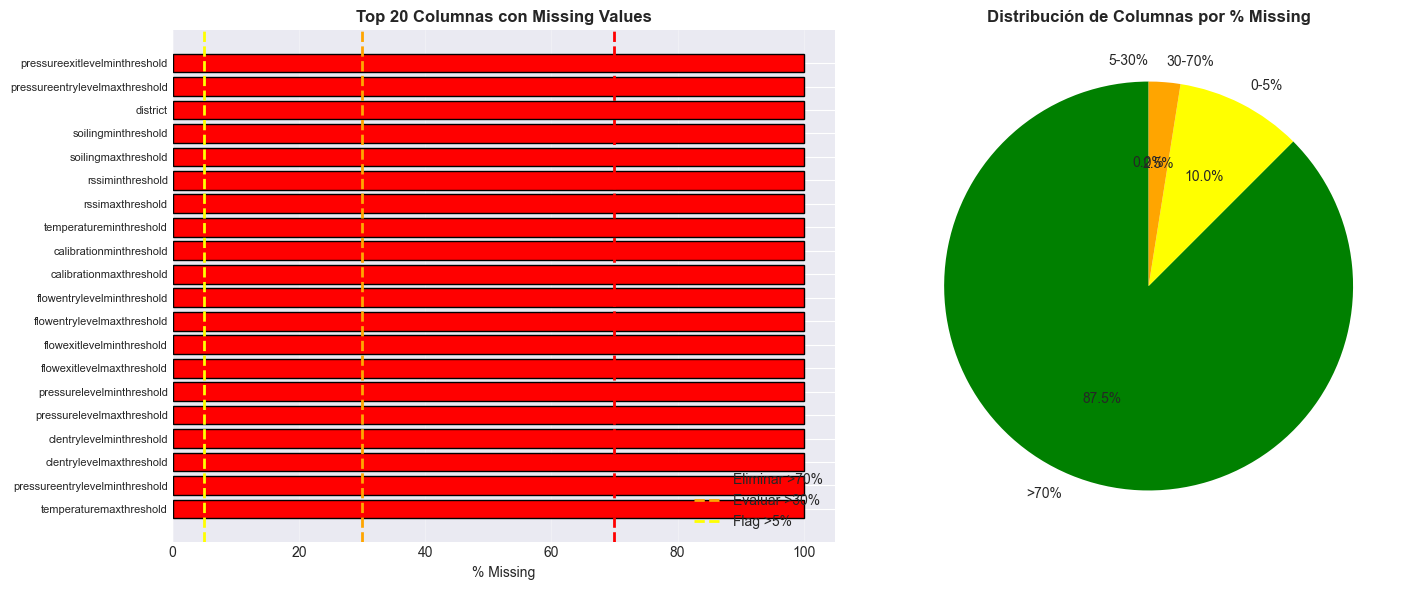


🗑️ COLUMNAS A ELIMINAR (70):


,column,missing_pct,dtype,unique_values
temperaturemaxthreshold,temperaturemaxthreshold,100.00,float64,0
district,district,100.00,float64,0
soilingminthreshold,soilingminthreshold,100.00,float64,0
soilingmaxthreshold,soilingmaxthreshold,100.00,float64,0
rssiminthreshold,rssiminthreshold,100.00,float64,0
rssimaxthreshold,rssimaxthreshold,100.00,float64,0
temperatureminthreshold,temperatureminthreshold,100.00,float64,0
calibrationminthreshold,calibrationminthreshold,100.00,float64,0
calibrationmaxthreshold,calibrationmaxthreshold,100.00,float64,0
flowentrylevelminthreshold,flowentrylevelminthreshold,100.00,float64,0



⚠️ Eliminando 70 columnas...
✅ Columnas eliminadas: 103 → 33 (70 eliminadas)

⚠️ COLUMNAS A EVALUAR MANUALMENTE (2):
Estas columnas tienen 30-70% missing. Decisión manual requerida:


,column,missing_pct,dtype,unique_values
waterleavingtanks,waterleavingtanks,56.10,float64,757589
refwaterstation,refwaterstation,52.77,object,37



💡 Recomendación:
  1. Verificar si son variables críticas para el negocio
  2. Analizar patrón de missing (¿aleatorio o sistemático?)
  3. Considerar imputación avanzada (KNN, modelo ML) si es importante
  4. Si no es crítica, mejor eliminar

✅ IMPUTACIÓN SIMPLE (8 columnas):
  ✓ country                                  → imputado con moda
  ✓ zip                                      → imputado con moda
  ✓ zone                                     → imputado con moda
  ✓ location                                 → imputado con moda
  ✓ name                                     → imputado con moda
  ✓ municipality                             → imputado con moda
  ✓ province                                 → imputado con moda
  ✓ community                                → imputado con moda

✅ 8 columnas imputadas

✅ VERIFICACIÓN FINAL
  • Missing values restantes: 56482935
  • Columnas finales: 33
  • Filas: 51,881,820

⚠️ Aún hay 56482935 missing values en columnas a evaluar manualmente


In [6]:
# ============================================================================
# 4. ANÁLISIS DE VALORES FALTANTES
# ============================================================================

print("\n" + "="*70)
print("🔍 ANÁLISIS Y GESTIÓN DE VALORES MISSING")
print("="*70)

# Calcular estadísticas de missing por columna
missing_stats = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes.values,
    'unique_values': [df[col].nunique() for col in df.columns]
})

missing_stats = missing_stats[missing_stats['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"\n📊 Resumen:")
print(f"  • Total columnas: {len(df.columns)}")
print(f"  • Columnas con missing: {len(missing_stats)}")
print(f"  • Columnas completas: {len(df.columns) - len(missing_stats)}")

if len(missing_stats) > 0:
    print(f"\n⚠️ Top 10 columnas con más missing:")
    display(missing_stats.head(10))

# ============= CRITERIOS DE DECISIÓN =============
print("\n" + "="*70)
print("📋 CRITERIOS DE DECISIÓN")
print("="*70)

# Umbrales recomendados
THRESHOLD_DROP = 70      # Eliminar si >70% missing
THRESHOLD_IMPUTE = 30    # Imputar si 5-30% missing
THRESHOLD_FLAG = 5       # Crear flag si 5-30% missing

print(f"""
Estrategia recomendada por % de missing:

  📍 0-5%:     MANTENER Y IMPUTAR
               → Pérdida mínima de información
               → Imputar con mediana (numérica) o moda (categórica)

  📍 5-30%:    MANTENER + IMPUTAR + FLAG
               → Imputar valores
               → Crear variable binaria indicando missing (puede ser informativa)
               → Ejemplo: 'clexitlevel_was_missing'

  📍 30-70%:   EVALUAR CASO POR CASO
               → Si es variable clave (target): MANTENER e imputar con modelo
               → Si es feature secundaria: EVALUAR importancia con modelo
               → Considerar si missing tiene patrón (no aleatorio)

  📍 >70%:     ELIMINAR
               → Muy poca información útil
               → Alto riesgo de bias por imputación
               → Excepción: variable de negocio crítica

Umbrales configurados:
  • Eliminar automáticamente: >{THRESHOLD_DROP}% missing
  • Imputar con flag:         {THRESHOLD_FLAG}-{THRESHOLD_IMPUTE}% missing
  • Imputar simple:           <{THRESHOLD_FLAG}% missing
""")

# ============= CLASIFICACIÓN DE COLUMNAS =============
cols_to_drop = []
cols_to_impute_simple = []
cols_to_impute_with_flag = []
cols_to_evaluate = []

for _, row in missing_stats.iterrows():
    col = row['column']
    pct = row['missing_pct']
    
    if pct > THRESHOLD_DROP:
        cols_to_drop.append(col)
    elif pct > THRESHOLD_IMPUTE:
        cols_to_evaluate.append(col)
    elif pct > THRESHOLD_FLAG:
        cols_to_impute_with_flag.append(col)
    else:
        cols_to_impute_simple.append(col)

print("\n📊 CLASIFICACIÓN DE COLUMNAS:")
print("="*70)
print(f"  🗑️  ELIMINAR (>{THRESHOLD_DROP}%):              {len(cols_to_drop)} columnas")
print(f"  ⚠️  EVALUAR (30-70%):           {len(cols_to_evaluate)} columnas")
print(f"  🏷️  IMPUTAR + FLAG ({THRESHOLD_FLAG}-{THRESHOLD_IMPUTE}%):    {len(cols_to_impute_with_flag)} columnas")
print(f"  ✅ IMPUTAR SIMPLE (<{THRESHOLD_FLAG}%):      {len(cols_to_impute_simple)} columnas")

# ============= VISUALIZACIÓN =============
if len(missing_stats) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico 1: Missing por columna (top 20)
    top_missing = missing_stats.head(20).sort_values('missing_pct')
    colors = ['red' if x > THRESHOLD_DROP else 'orange' if x > THRESHOLD_IMPUTE else 'yellow' if x > THRESHOLD_FLAG else 'green' 
              for x in top_missing['missing_pct']]
    
    axes[0].barh(range(len(top_missing)), top_missing['missing_pct'], color=colors, edgecolor='black')
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['column'], fontsize=8)
    axes[0].axvline(THRESHOLD_DROP, color='red', linestyle='--', linewidth=2, label=f'Eliminar >{THRESHOLD_DROP}%')
    axes[0].axvline(THRESHOLD_IMPUTE, color='orange', linestyle='--', linewidth=2, label=f'Evaluar >{THRESHOLD_IMPUTE}%')
    axes[0].axvline(THRESHOLD_FLAG, color='yellow', linestyle='--', linewidth=2, label=f'Flag >{THRESHOLD_FLAG}%')
    axes[0].set_xlabel('% Missing')
    axes[0].set_title('Top 20 Columnas con Missing Values', fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Gráfico 2: Distribución de missing
    bins = [0, THRESHOLD_FLAG, THRESHOLD_IMPUTE, THRESHOLD_DROP, 100]
    labels = [f'0-{THRESHOLD_FLAG}%', f'{THRESHOLD_FLAG}-{THRESHOLD_IMPUTE}%', 
              f'{THRESHOLD_IMPUTE}-{THRESHOLD_DROP}%', f'>{THRESHOLD_DROP}%']
    missing_stats['category'] = pd.cut(missing_stats['missing_pct'], bins=bins, labels=labels)
    
    category_counts = missing_stats['category'].value_counts()
    colors_pie = ['green', 'yellow', 'orange', 'red']
    axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
                colors=colors_pie, startangle=90)
    axes[1].set_title('Distribución de Columnas por % Missing', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ============= DETALLES DE COLUMNAS A ELIMINAR =============
if len(cols_to_drop) > 0:
    print(f"\n🗑️ COLUMNAS A ELIMINAR ({len(cols_to_drop)}):")
    print("="*70)
    drop_details = missing_stats[missing_stats['column'].isin(cols_to_drop)][
        ['column', 'missing_pct', 'dtype', 'unique_values']
    ]
    display(drop_details)
    
    # ELIMINAR
    print(f"\n⚠️ Eliminando {len(cols_to_drop)} columnas...")
    df_before = df.shape[1]
    df = df.drop(columns=cols_to_drop)
    print(f"✅ Columnas eliminadas: {df_before} → {df.shape[1]} ({df_before - df.shape[1]} eliminadas)")

# ============= DETALLES DE COLUMNAS A EVALUAR =============
if len(cols_to_evaluate) > 0:
    print(f"\n⚠️ COLUMNAS A EVALUAR MANUALMENTE ({len(cols_to_evaluate)}):")
    print("="*70)
    print("Estas columnas tienen 30-70% missing. Decisión manual requerida:")
    
    eval_details = missing_stats[missing_stats['column'].isin(cols_to_evaluate)][
        ['column', 'missing_pct', 'dtype', 'unique_values']
    ]
    display(eval_details)
    
    print("\n💡 Recomendación:")
    print("  1. Verificar si son variables críticas para el negocio")
    print("  2. Analizar patrón de missing (¿aleatorio o sistemático?)")
    print("  3. Considerar imputación avanzada (KNN, modelo ML) si es importante")
    print("  4. Si no es crítica, mejor eliminar")

# ============= IMPUTACIÓN CON FLAG =============
if len(cols_to_impute_with_flag) > 0:
    print(f"\n🏷️ IMPUTACIÓN CON FLAG ({len(cols_to_impute_with_flag)} columnas):")
    print("="*70)
    
    for col in cols_to_impute_with_flag:
        # Crear columna flag
        flag_col = f"{col}_was_missing"
        df[flag_col] = df[col].isnull().astype(int)
        
        # Imputar
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            method = 'mediana'
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            method = 'moda'
        
        print(f"  ✓ {col:40s} → imputado con {method}, flag creado")
    
    print(f"\n✅ {len(cols_to_impute_with_flag)} columnas imputadas con flag")

# ============= IMPUTACIÓN SIMPLE =============
if len(cols_to_impute_simple) > 0:
    print(f"\n✅ IMPUTACIÓN SIMPLE ({len(cols_to_impute_simple)} columnas):")
    print("="*70)
    
    for col in cols_to_impute_simple:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            method = 'mediana'
        else:
            df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)
            method = 'moda'
        
        print(f"  ✓ {col:40s} → imputado con {method}")
    
    print(f"\n✅ {len(cols_to_impute_simple)} columnas imputadas")

# ============= VERIFICACIÓN FINAL =============
print("\n" + "="*70)
print("✅ VERIFICACIÓN FINAL")
print("="*70)

remaining_missing = df.isnull().sum().sum()
print(f"  • Missing values restantes: {remaining_missing}")
print(f"  • Columnas finales: {df.shape[1]}")
print(f"  • Filas: {df.shape[0]:,}")

if remaining_missing > 0:
    print(f"\n⚠️ Aún hay {remaining_missing} missing values en columnas a evaluar manualmente")
    remaining_cols = df.columns[df.isnull().any()].tolist()
    print(f"  Columnas: {remaining_cols}")
else:
    print("\n🎉 ¡No quedan missing values en el dataset!")

# ============= RESUMEN DE ACCIONES =============
print("\n" + "="*70)
print("📝 RESUMEN DE ACCIONES TOMADAS")
print("="*70)
print(f"""
  🗑️  Columnas eliminadas:           {len(cols_to_drop)}
  🏷️  Columnas imputadas con flag:   {len(cols_to_impute_with_flag)}
  ✅ Columnas imputadas simple:      {len(cols_to_impute_simple)}
  ⚠️  Columnas pendientes evaluación: {len(cols_to_evaluate)}
  
  📊 Dataset final:
     Antes: {df_before if len(cols_to_drop) > 0 else len(df.columns) + len(cols_to_drop)} columnas
     Ahora: {df.shape[1]} columnas
     Nuevas columnas flag: {len(cols_to_impute_with_flag)}
""")

In [7]:
df.columns

Index(['entityid', 'entitytype', 'fiwareservicepath', 'timeinstant',
       'clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel',
       'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel',
       'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor',
       'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross',
       'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel',
       'location', 'name', 'refwaterstation', 'zip', 'zone', 'municipality',
       'province', 'community', 'country'],
      dtype='object')

In [8]:
# Se eliminan las columnas que no se van a usar para la predicción de demanda futura de agua y niveles y diversas magnitudes de los tanques

columnas_a_eliminar = [
    'entitytype', 'fiwareservicepath', 'zip', 'zone', 'municipality', 'community', 'country', 'refwaterstation'
]

df = df.drop(columns=columnas_a_eliminar, errors='ignore')
print(f"Columnas restantes: {len(df.columns)}")
print(df.columns.tolist())

Columnas restantes: 25
['entityid', 'timeinstant', 'clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel', 'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel', 'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor', 'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross', 'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel', 'location', 'name', 'province']


In [9]:
# ============================================================================
# 5. EXTRACCIÓN DE PROVINCIAS
# ============================================================================
# Mapeo de códigos a provincias (primeras 2 letras de entityid)
provincias_map = {
    'AV': 'Ávila', 'SO': 'Soria', 'BU': 'Burgos', 'PA': 'Palencia',
    'LE': 'León', 'VA': 'Valladolid', 'ZA': 'Zamora', 'SA': 'Salamanca', 
    'SG': 'Segovia'
}

# Extraer provincia del entityid
df['province'] = df['entityid'].str[:2].map(provincias_map)

# Si no existe, usar el campo province original
if 'province_original' not in df.columns and 'province' in df.columns:
    df['province_original'] = df['province']
    
print(f"\n📍 Provincias identificadas: {df['province'].nunique()}")
print(df['province'].value_counts())


📍 Provincias identificadas: 9
province
Palencia      22297676
Ávila         18378273
Valladolid     4259891
León           2292339
Segovia        2136375
Burgos         1024191
Salamanca       823808
Soria           505476
Zamora           83460
Name: count, dtype: int64


In [10]:
# ============================================================================
# 6. IDENTIFICACIÓN DE TANQUES
# ============================================================================
# Análisis por tanque (entityid)
n_tanks = df['entityid'].nunique()
print(f"\n🏭 Total de tanques: {n_tanks}")

# Registros por tanque
tank_counts = df.groupby('entityid').size().sort_values(ascending=False)
print(f"\nTop 5 tanques con más registros:")
print(tank_counts.head())


🏭 Total de tanques: 281

Top 5 tanques con más registros:
entityid
PA_FROMI_AGU_0002    6619087
PA_POBCA_AGU_0001    6298662
PA_ITEVE_AGU_0001    2636452
LE_OZUPO_AGU_0001    1808989
PA_BOACA_AGU_0001    1505120
dtype: int64


In [11]:
# ============================================================================
# 7. TIPAR VARIABLES
# ============================================================================
# Variables numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables categóricas (object o category)
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Variables binarias (solo 2 valores únicos)
binarias = [col for col in df.columns if df[col].nunique() == 2]

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)
print("Variables binarias:", binarias)

Variables numéricas: ['clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel', 'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel', 'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor', 'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross', 'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel']
Variables categóricas: ['entityid', 'timeinstant', 'location', 'name', 'province', 'province_original']
Variables binarias: []


In [12]:
# ============================================================================
# 8. TRATAMIENTO DE VARIABLES NUMÉRICAS
# ============================================================================

# IDENTIFICAR VARIABLES NUMÉRICAS

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n📌 Variables numéricas detectadas:")
print(numeric_cols)


# 1. ELIMINAR DUPLICADOS

print("\n" + "="*70)
print("1️⃣ ELIMINACIÓN DE DUPLICADOS")
print("="*70)

n_duplicates = df.duplicated().sum()
print(f"  • Filas duplicadas: {n_duplicates:,}")

if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f"  ✅ Eliminadas {n_duplicates:,} filas duplicadas")


# 2. FILAS CON >50% MISSING

print("\n" + "="*70)
print("2️⃣ FILAS CON MUCHOS VALORES MISSING")
print("="*70)

THRESHOLD_ROW_MISSING = 50

missing_per_row = (df.isnull().sum(axis=1) / df.shape[1]) * 100
rows_to_drop = missing_per_row > THRESHOLD_ROW_MISSING

print(f"  • Filas a eliminar (> {THRESHOLD_ROW_MISSING}% missing): {rows_to_drop.sum():,}")

df = df[~rows_to_drop]
print("  ✅ Filas con demasiados missing eliminadas")


# 3. OUTLIERS EXTREMOS EN VARIABLES NUMÉRICAS

print("\n" + "="*70)
print("3️⃣ OUTLIERS EXTREMOS")
print("="*70)

OUTLIER_THRESHOLD = 6  # 6 sigmas

outlier_counts = {}

for col in numeric_cols:
    if df[col].notna().sum() > 50:  # evitar columnas pequeñas
        mean, std = df[col].mean(), df[col].std()
        if std > 0:
            mask = ((df[col] - mean).abs() > OUTLIER_THRESHOLD * std)
            n_outliers = mask.sum()
            if n_outliers > 0:
                outlier_counts[col] = n_outliers

if outlier_counts:
    print("\n📊 Outliers detectados:")
    for col, n in outlier_counts.items():
        print(f"   • {col}: {n:,}")
    
    REMOVE_OUTLIERS = False  # cambia a True si quieres eliminarlos

    if REMOVE_OUTLIERS:
        for col in outlier_counts.keys():
            mean, std = df[col].mean(), df[col].std()
            df = df[((df[col] - mean).abs() <= OUTLIER_THRESHOLD * std)]
        print("\n✅ Outliers eliminados")
    else:
        print("\n✅ Outliers mantenidos (recomendado para EDA)")
else:
    print("✅ No se detectaron outliers extremos")


# 4. VALORES IMPOSIBLES AUTOMÁTICOS

print("\n" + "="*70)
print("4️⃣ VALORES IMPOSIBLES EN VARIABLES NUMÉRICAS")
print("="*70)

#rows_to_drop_invalid = pd.Series([False]*len(df))
rows_to_drop_invalid = pd.Series(False, index=df.index)

# regla genérica: infinitos o no numéricos
for col in numeric_cols:
    invalid = ~np.isfinite(df[col])
    if invalid.sum() > 0:
        rows_to_drop_invalid |= invalid
        print(f"  ⚠️ {col}: {invalid.sum():,} valores no finitos detectados")

if rows_to_drop_invalid.sum() > 0:
    df = df[~rows_to_drop_invalid]
    print(f"\n✅ Eliminadas {rows_to_drop_invalid.sum():,} filas inválidas")
else:
    print("✅ No se encontraron valores imposibles")


# 5. RESUMEN FINAL

print("\n" + "="*70)
print("📊 RESUMEN DE LIMPIEZA")
print("="*70)

print(f"✅ Filas finales: {len(df):,}")
print(f"✅ Columnas finales: {df.shape[1]}")
print(f"✅ Missing total: {df.isnull().sum().sum():,}")
print(f"✅ Variables numéricas: {len(numeric_cols)}")
print("\n🎯 Dataset listo para EDA o modelado")


📌 Variables numéricas detectadas:
['clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel', 'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel', 'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor', 'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross', 'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel']

1️⃣ ELIMINACIÓN DE DUPLICADOS
  • Filas duplicadas: 0

2️⃣ FILAS CON MUCHOS VALORES MISSING
  • Filas a eliminar (> 50% missing): 0
  ✅ Filas con demasiados missing eliminadas

3️⃣ OUTLIERS EXTREMOS

📊 Outliers detectados:
   • clexitlevel: 991
   • clinjector: 1,052,981
   • cltanklevel: 991
   • phexitlevel: 155,080
   • waterleavingtanks: 97,243
   • waterturbidityexitlevel: 7,093
   • orpexitlevel: 108,693
   • rssi: 1,636

✅ Outliers mantenidos (recomendado para EDA)

4️⃣ VALORES IMPOSIBLES EN VARIABLES NUMÉRICAS
  ⚠️ waterleavingtanks: 29,106,486 valores no finitos detectados

✅ Eliminadas 29,106,486 filas inválidas

📊 RESU

In [13]:
# ============================================================================
# 9. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
# ============================================================================

print("\n" + "="*80)
print("9. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

numeric_cols = [col for col in numericas if col in df.columns]
print(df[numeric_cols].describe().T)


9. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
                              count     mean      std        min    25%  \
clexitlevel             22775334.00   -72.14  6617.86 -999999.00   0.18   
clinjector              22775334.00     0.12     0.07       0.00   0.06   
cltanklevel             22775334.00   -57.85  5294.29 -799999.20   0.06   
phexitlevel             22775334.00 -6802.72 82235.90 -999999.00   5.83   
waterleavingtanks       22775334.00  4879.80 50458.19     -23.00  -1.00   
watertanklevel          22775334.00   293.93   125.54      -0.74 193.90   
waterturbidityexitlevel 22775334.00   536.66 17669.88 -999999.00  42.30   
orpexitlevel            22775334.00   161.35    23.44     100.00 143.00   
soiling                 22775334.00    45.44    21.79       5.00  27.00   
rssi                    22775334.00    89.99    19.20     -77.00  74.00   
temperature             22775334.00    22.56    13.17       0.00  11.20   
nasensor                22775334.00    15.06    

In [14]:
# ============================================================================
# 10. ANÁLISIS DE COLUMNAS CATEGÓRICAS
# ============================================================================

print("\n" + "="*80)
print("10. ANÁLISIS DE COLUMNAS CATEGÓRICAS")
print("="*80)

for col in categoricas:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Valores únicos: {df[col].nunique()}")
        if df[col].nunique() <= 20:
            print(f"  Distribución:\n{df[col].value_counts()}")



10. ANÁLISIS DE COLUMNAS CATEGÓRICAS

ENTITYID:
  Valores únicos: 99

TIMEINSTANT:
  Valores únicos: 22115003

LOCATION:
  Valores únicos: 87

NAME:
  Valores únicos: 86

PROVINCE:
  Valores únicos: 6
  Distribución:
province
Palencia      21136995
Ávila           838351
Salamanca       358530
Soria           342762
Burgos           44649
Valladolid       32702
Name: count, dtype: int64

PROVINCE_ORIGINAL:
  Valores únicos: 6
  Distribución:
province_original
Palencia      21136995
Ávila           838351
Salamanca       358530
Soria           342762
Burgos           44649
Valladolid       32702
Name: count, dtype: int64


In [15]:
# Identificar columnas categóricas
print("\n Identificando columnas categóricas...")
for col in df.select_dtypes(include=['object']).columns:
    unique_ratio = df[col].nunique() / len(df)
    print(f"   {col}: {df[col].nunique()} valores únicos ({unique_ratio*100:.2f}%)")
    
    if unique_ratio < 0.5:  # Si menos del 50% son únicos
        df[col] = df[col].astype('category')
        print(f"   ✓ Convertido a category")


 Identificando columnas categóricas...
   entityid: 99 valores únicos (0.00%)
   ✓ Convertido a category
   timeinstant: 22115003 valores únicos (97.10%)
   location: 87 valores únicos (0.00%)
   ✓ Convertido a category
   name: 86 valores únicos (0.00%)
   ✓ Convertido a category
   province: 6 valores únicos (0.00%)
   ✓ Convertido a category
   province_original: 6 valores únicos (0.00%)
   ✓ Convertido a category


In [16]:
df[numeric_cols]

,clexitlevel,clinjector,cltanklevel,phexitlevel,waterleavingtanks,watertanklevel,waterturbidityexitlevel,orpexitlevel,soiling,rssi,temperature,nasensor,calibration,flowexitlevel,pressurelevel,clslope,clgross,pressureexitlevel,temperatureexitlevel,turbidityentrylevel
0,0.48,0.11,0.18,7.52,360.00,251.00,0.00,152.00,72.00,86.00,2.50,17.89,45.00,11.13,2.37,25.00,106.11,5.96,19.50,804.60
1,0.40,0.07,0.06,6.21,587.30,201.20,1437.10,120.00,63.00,84.00,14.20,18.32,36.00,16.93,2.21,25.00,126.73,3.57,18.40,567.60
2,0.22,0.05,0.15,6.09,929.36,391.50,1268.20,169.00,76.00,80.00,33.50,10.86,61.00,12.76,4.85,27.00,107.51,3.42,13.20,899.30
5,0.15,0.20,0.11,6.84,929.37,266.60,1191.20,146.00,52.00,86.00,24.10,17.40,16.00,16.96,0.52,32.00,137.23,3.40,12.70,852.80
9,0.23,0.23,0.05,5.55,231.50,223.80,1043.80,157.00,48.00,64.00,1.00,19.99,42.00,19.00,4.50,17.00,111.07,3.03,17.50,1108.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51881807,0.32,0.18,0.03,6.26,0.00,118.50,1085.70,187.00,73.00,105.00,20.10,18.70,42.00,6.09,0.72,27.00,148.14,0.53,12.70,615.40
51881809,0.15,0.01,0.17,6.88,1576.97,134.20,1116.30,176.00,12.00,89.00,33.30,15.48,15.00,12.34,3.95,21.00,146.82,3.75,19.50,1367.00
51881813,0.18,0.10,0.23,6.29,1205.80,141.10,1170.50,159.00,46.00,98.00,7.40,15.31,43.00,19.02,4.50,33.00,158.01,2.53,18.60,1264.60
51881814,0.37,0.04,0.10,5.53,1576.99,274.60,1085.30,249.00,54.00,104.00,8.60,12.59,60.00,15.04,1.45,19.00,114.70,1.14,17.00,1015.20



11. DISTRIBUCIONES DE VARIABLES PRINCIPALES


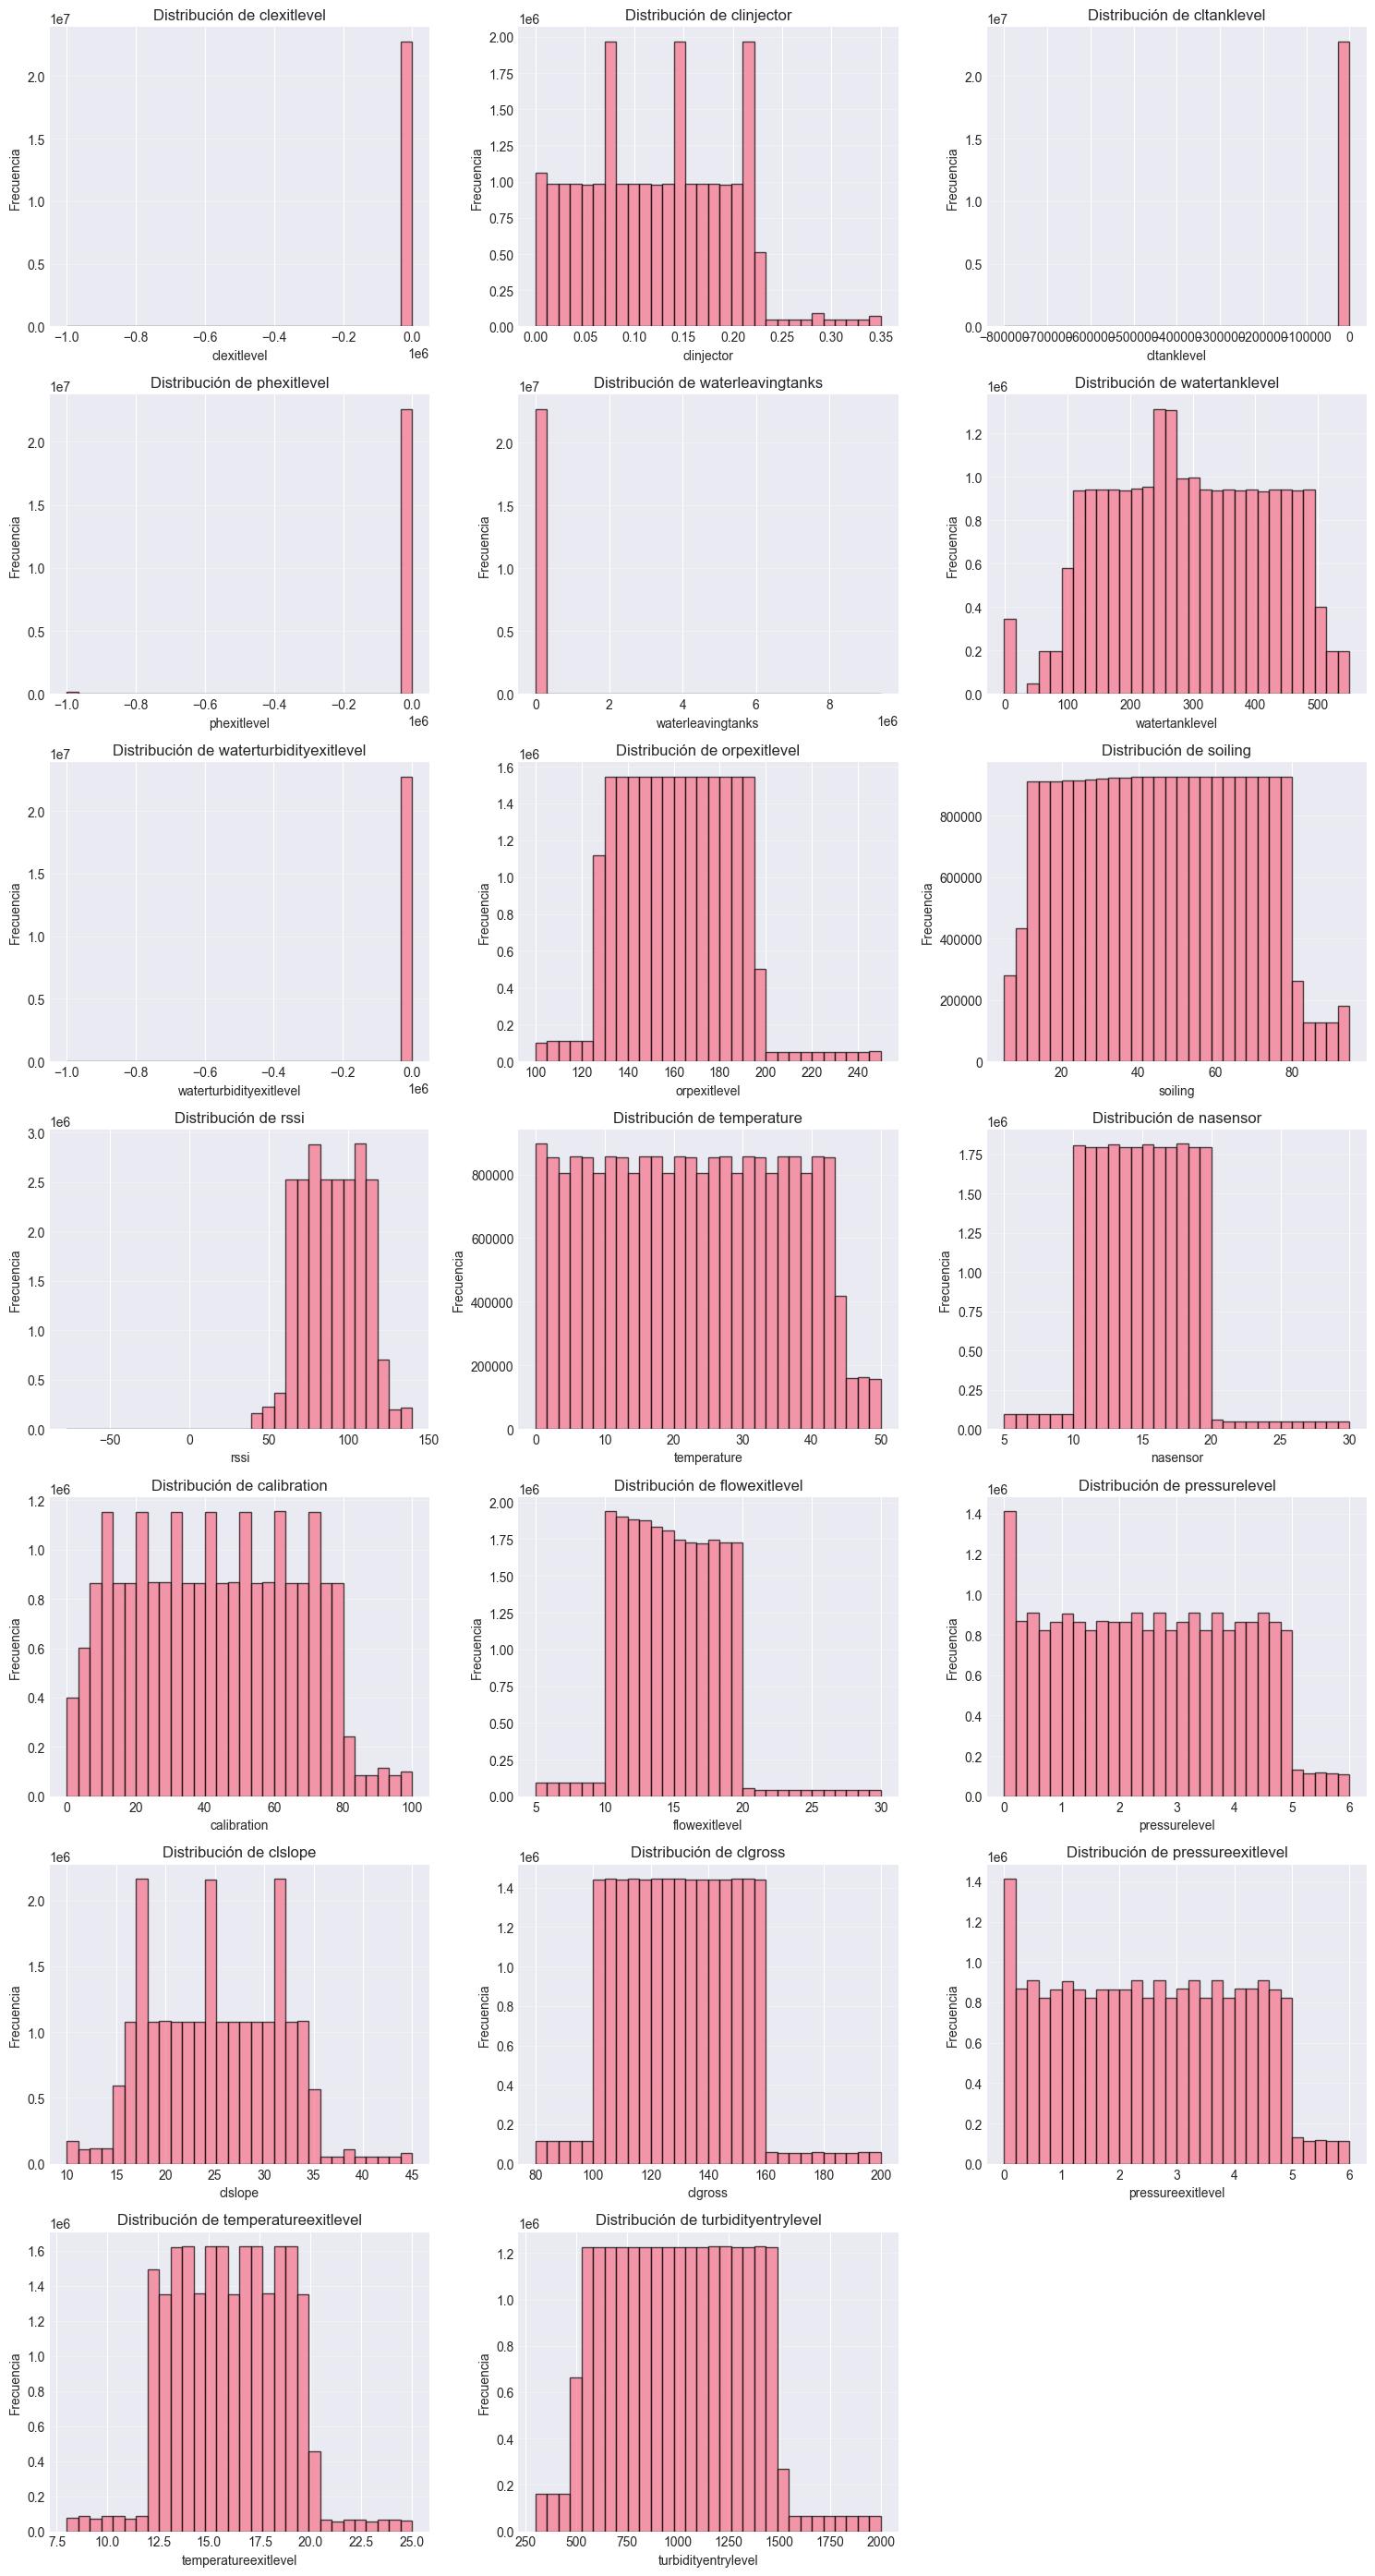

In [17]:
# ============================================================================
# 11. DISTRIBUCIONES DE VARIABLES PRINCIPALES
# ============================================================================

print("\n" + "="*80)
print("11. DISTRIBUCIONES DE VARIABLES PRINCIPALES")
print("="*80)

# Seleccionar variables clave para visualización
#key_vars = ['battery', 'clexitlevel', 'phexitlevel', 'watertanklevel',
            #'temperature', 'rssi', 'pressurelevel', 'watertanklevelpercentage', 'waterleavingtanks']
key_vars = numeric_cols
key_vars = [v for v in key_vars if v in df.columns and df[v].notna().sum() > 0]

if key_vars:
    n_cols = 3
    n_rows = (len(key_vars) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, var in enumerate(key_vars):
        data = df[var].dropna()
        if len(data) > 0:
            axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribución de {var}')
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('Frecuencia')
            axes[idx].grid(axis='y', alpha=0.3)
    
    # Ocultar subplots vacíos
    for idx in range(len(key_vars), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


12. DETECCIÓN DE OUTLIERS


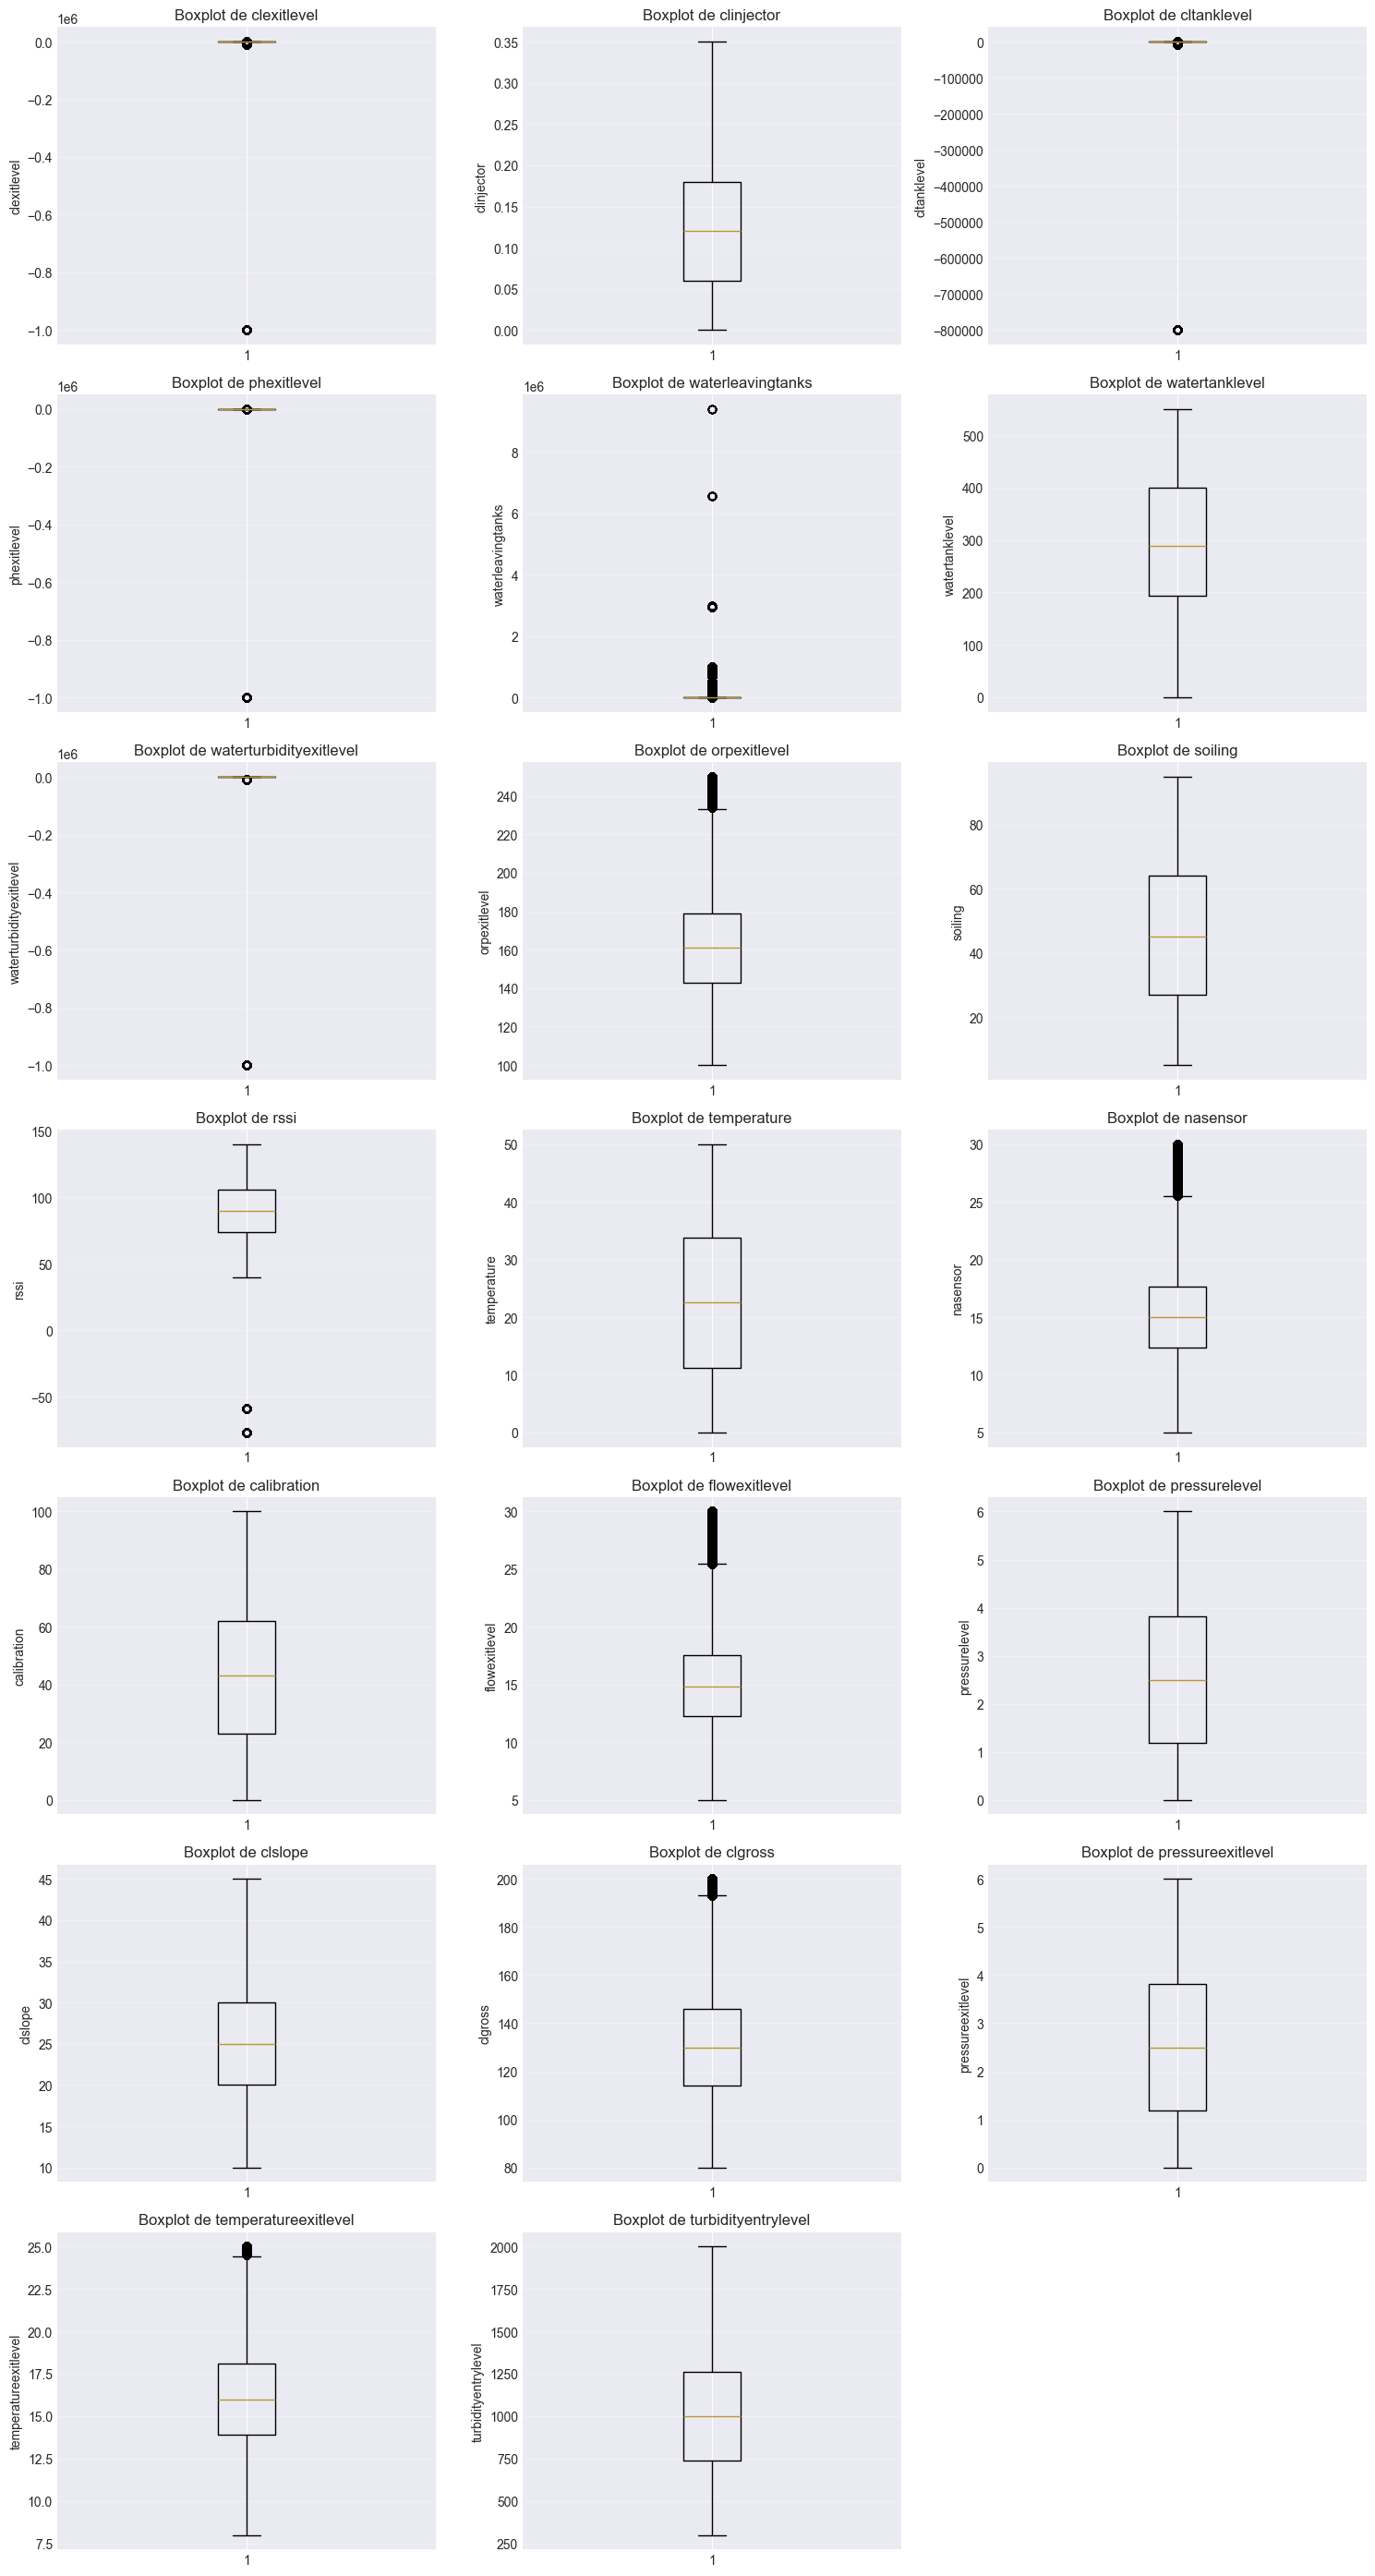

In [18]:
# ============================================================================
# 12. DETECCIÓN DE OUTLIERS (BOXPLOTS)
# ============================================================================

print("\n" + "="*80)
print("12. DETECCIÓN DE OUTLIERS")
print("="*80)

if key_vars:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, var in enumerate(key_vars):
        data = df[var].dropna()
        if len(data) > 0:
            axes[idx].boxplot(data, vert=True)
            axes[idx].set_title(f'Boxplot de {var}')
            axes[idx].set_ylabel(var)
            axes[idx].grid(axis='y', alpha=0.3)
    
    for idx in range(len(key_vars), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [19]:
print(df['timeinstant'].dtype)

object


In [20]:
# Se eliminan los registros que contienen un valor negativo en cualquiera de las columnas numéricas ya que se entiende que son medidas erroneas
df = df[(df[numeric_cols] >= 0).all(axis=1)]

# Convertir 'timeinstant' a datetime si no lo está ya
df['timeinstant'] = pd.to_datetime(df['timeinstant'], utc=True, errors='coerce')

# Obtener la fecha actual
fecha_actual = pd.Timestamp.now(tz='UTC')

# Filtrar: mantener solo registros con fecha <= actual
df = df[df['timeinstant'] <= fecha_actual]

# Agrupa por provincia el número de registros
print(df['province'].value_counts())

province
Palencia      14629892
Ávila           676922
Salamanca       358472
Soria           342684
Burgos           44649
Valladolid       32702
Name: count, dtype: int64


In [21]:
#Ver los tipos de datos de todas las columas
print("="*60)
print("TIPOS DE DATOS DE TODAS LAS COLUMNAS")
print("="*60)
for columna in df.columns:
    print(f"{columna:30s} -> {df[columna].dtype}")

TIPOS DE DATOS DE TODAS LAS COLUMNAS
entityid                       -> category
timeinstant                    -> datetime64[ns, UTC]
clexitlevel                    -> float64
clinjector                     -> float64
cltanklevel                    -> float64
phexitlevel                    -> float64
waterleavingtanks              -> float64
watertanklevel                 -> float64
waterturbidityexitlevel        -> float64
orpexitlevel                   -> float64
soiling                        -> float64
rssi                           -> float64
temperature                    -> float64
nasensor                       -> float64
calibration                    -> float64
flowexitlevel                  -> float64
pressurelevel                  -> float64
clslope                        -> float64
clgross                        -> float64
pressureexitlevel              -> float64
temperatureexitlevel           -> float64
turbidityentrylevel            -> float64
location                  

In [22]:
# Se convierte la columna timeinstant a formato datetime con control de errores
# Si hay valores problemáticos, convertirlos a NaT (Not a Time), se fuerza la conversión elimnando la zona horaria si es necesario
#df['timeinstant'] = pd.to_datetime(df['timeinstant'], errors='coerce')
#df['Period'] = pd.to_datetime(df['timeinstant'], format='%YM%m')
#df['timeinstant'] = pd.to_datetime(df['timeinstant'], utc=True, errors='coerce')

# Verificar el cambio de tipado y ver si hay valores que no se pudieron convertir
print(f"Tipo después de conversión: {df['timeinstant'].dtype}")
print(f"Valores NaT después de conversión: {df['timeinstant'].isna().sum()}")
print(df['timeinstant'].head())

Tipo después de conversión: datetime64[ns, UTC]
Valores NaT después de conversión: 0
0   2024-04-17 11:32:25.242000+00:00
1   2024-04-17 11:32:39.237000+00:00
2   2024-04-17 11:33:01.227000+00:00
5   2024-04-17 11:33:37.573000+00:00
9   2024-04-17 11:33:59.813000+00:00
Name: timeinstant, dtype: datetime64[ns, UTC]


In [23]:
print(df.columns.tolist())

['entityid', 'timeinstant', 'clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel', 'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel', 'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor', 'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross', 'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel', 'location', 'name', 'province', 'province_original']



13. ANÁLISIS DE CORRELACIONES


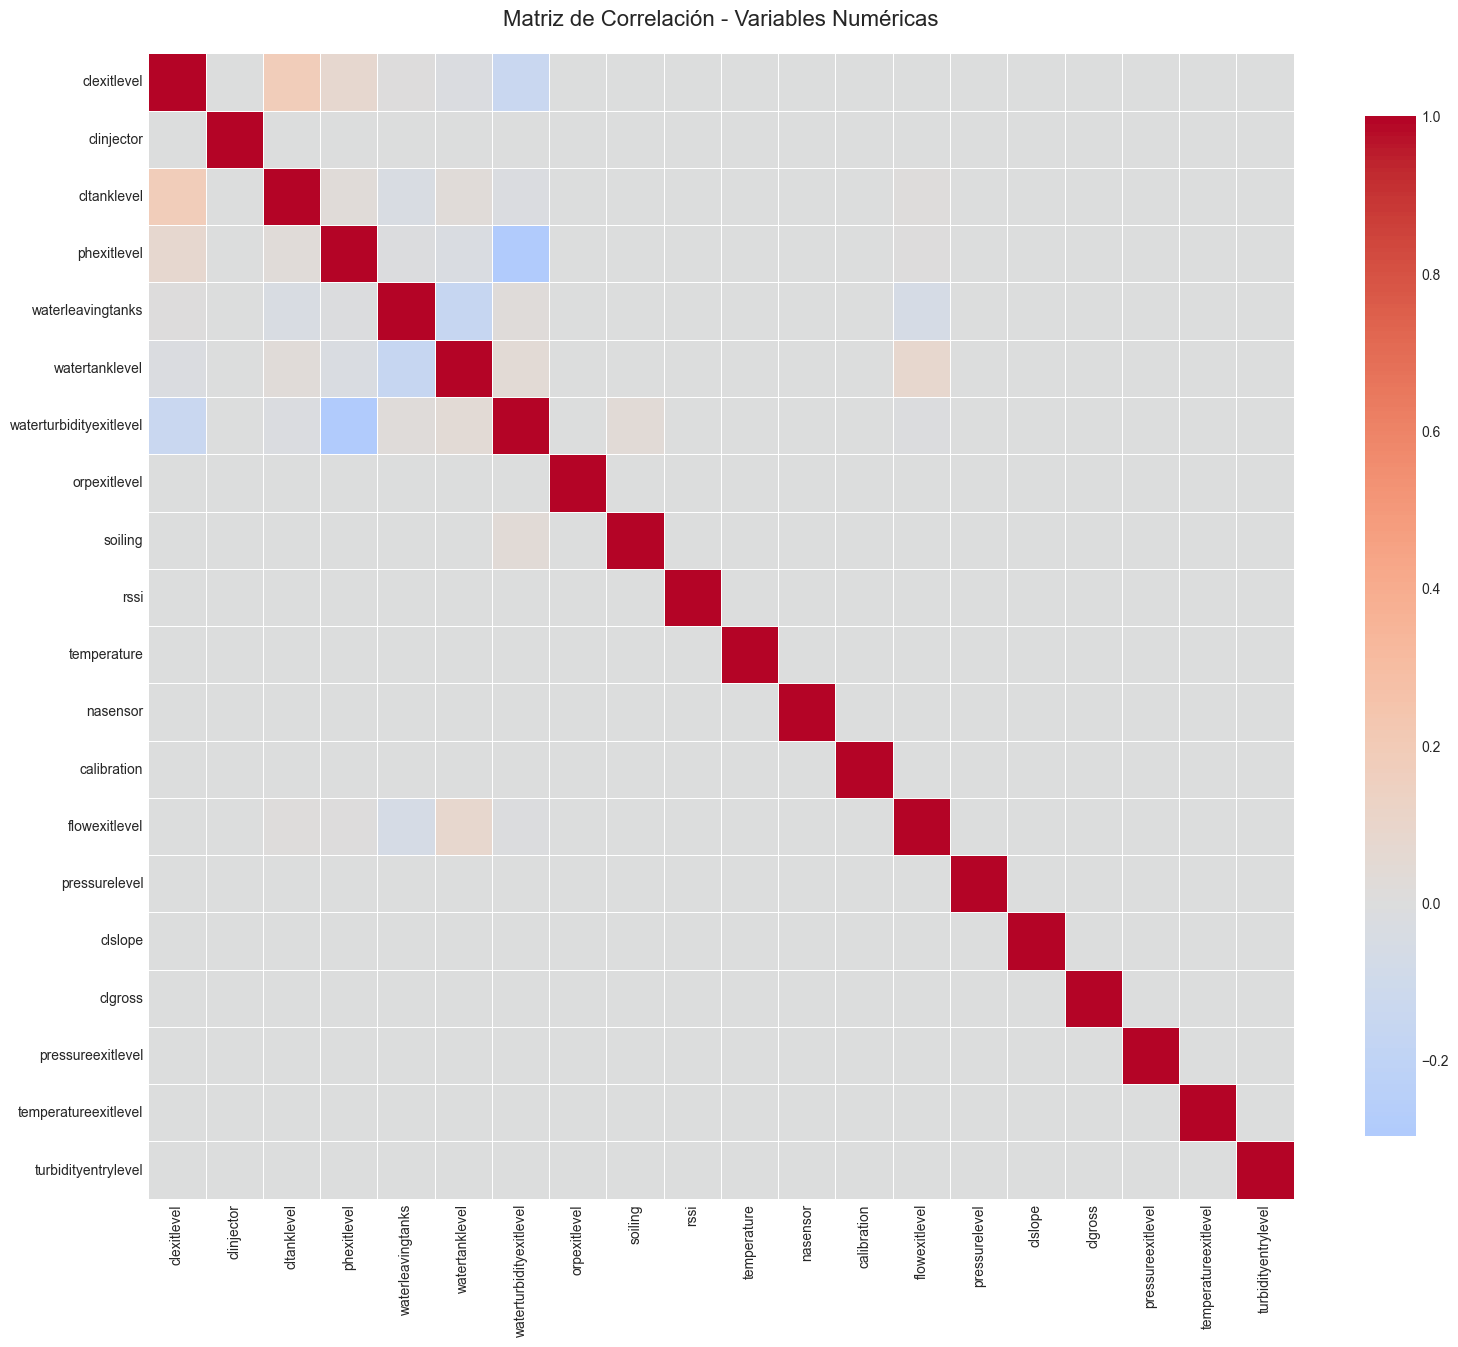


Correlaciones más fuertes (|r| > 0.7):
  clexitlevel <-> clexitlevel: 1.000
  clinjector <-> clinjector: 1.000
  cltanklevel <-> cltanklevel: 1.000
  phexitlevel <-> phexitlevel: 1.000
  waterleavingtanks <-> waterleavingtanks: 1.000
  watertanklevel <-> watertanklevel: 1.000
  waterturbidityexitlevel <-> waterturbidityexitlevel: 1.000
  orpexitlevel <-> orpexitlevel: 1.000
  soiling <-> soiling: 1.000
  rssi <-> rssi: 1.000
  temperature <-> temperature: 1.000
  nasensor <-> nasensor: 1.000
  calibration <-> calibration: 1.000
  flowexitlevel <-> flowexitlevel: 1.000
  pressurelevel <-> pressurelevel: 1.000
  clslope <-> clslope: 1.000
  clgross <-> clgross: 1.000
  pressureexitlevel <-> pressureexitlevel: 1.000
  temperatureexitlevel <-> temperatureexitlevel: 1.000
  turbidityentrylevel <-> turbidityentrylevel: 1.000
  waterturbidityexitlevel <-> phexitlevel: -0.296
  cltanklevel <-> clexitlevel: 0.183
  watertanklevel <-> waterleavingtanks: -0.159
  waterturbidityexitlevel <-> clex

In [24]:
# ============================================================================
# 13 ANÁLISIS DE CORRELACIONES
# ============================================================================

print("\n" + "="*80)
print("13. ANÁLISIS DE CORRELACIONES")
print("="*80)

# Seleccionar variables numéricas con suficientes datos
correlation_vars = [col for col in numeric_cols if df[col].notna().sum() > len(df) * 0.5]

if len(correlation_vars) > 1:
    correlation_matrix = df[correlation_vars].corr()
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Correlaciones más fuertes
    print("\nCorrelaciones más fuertes (|r| > 0.7):")
    high_corr = correlation_matrix.abs() > 0.7
    high_corr = high_corr.where(np.triu(np.ones(high_corr.shape), k=1).astype(bool))
    high_corr_pairs = [(correlation_matrix.index[i], correlation_matrix.columns[j], 
                        correlation_matrix.iloc[i, j])
                       for i in range(len(correlation_matrix.index))
                       for j in range(len(correlation_matrix.columns))
                       if high_corr.iloc[i, j]]
    
    if high_corr_pairs:
        for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {var1} <-> {var2}: {corr:.3f}")
    else:
        print("  No se encontraron correlaciones fuertes")


14. DISTRIBUCIONES DE VARIABLES PRINCIPALES


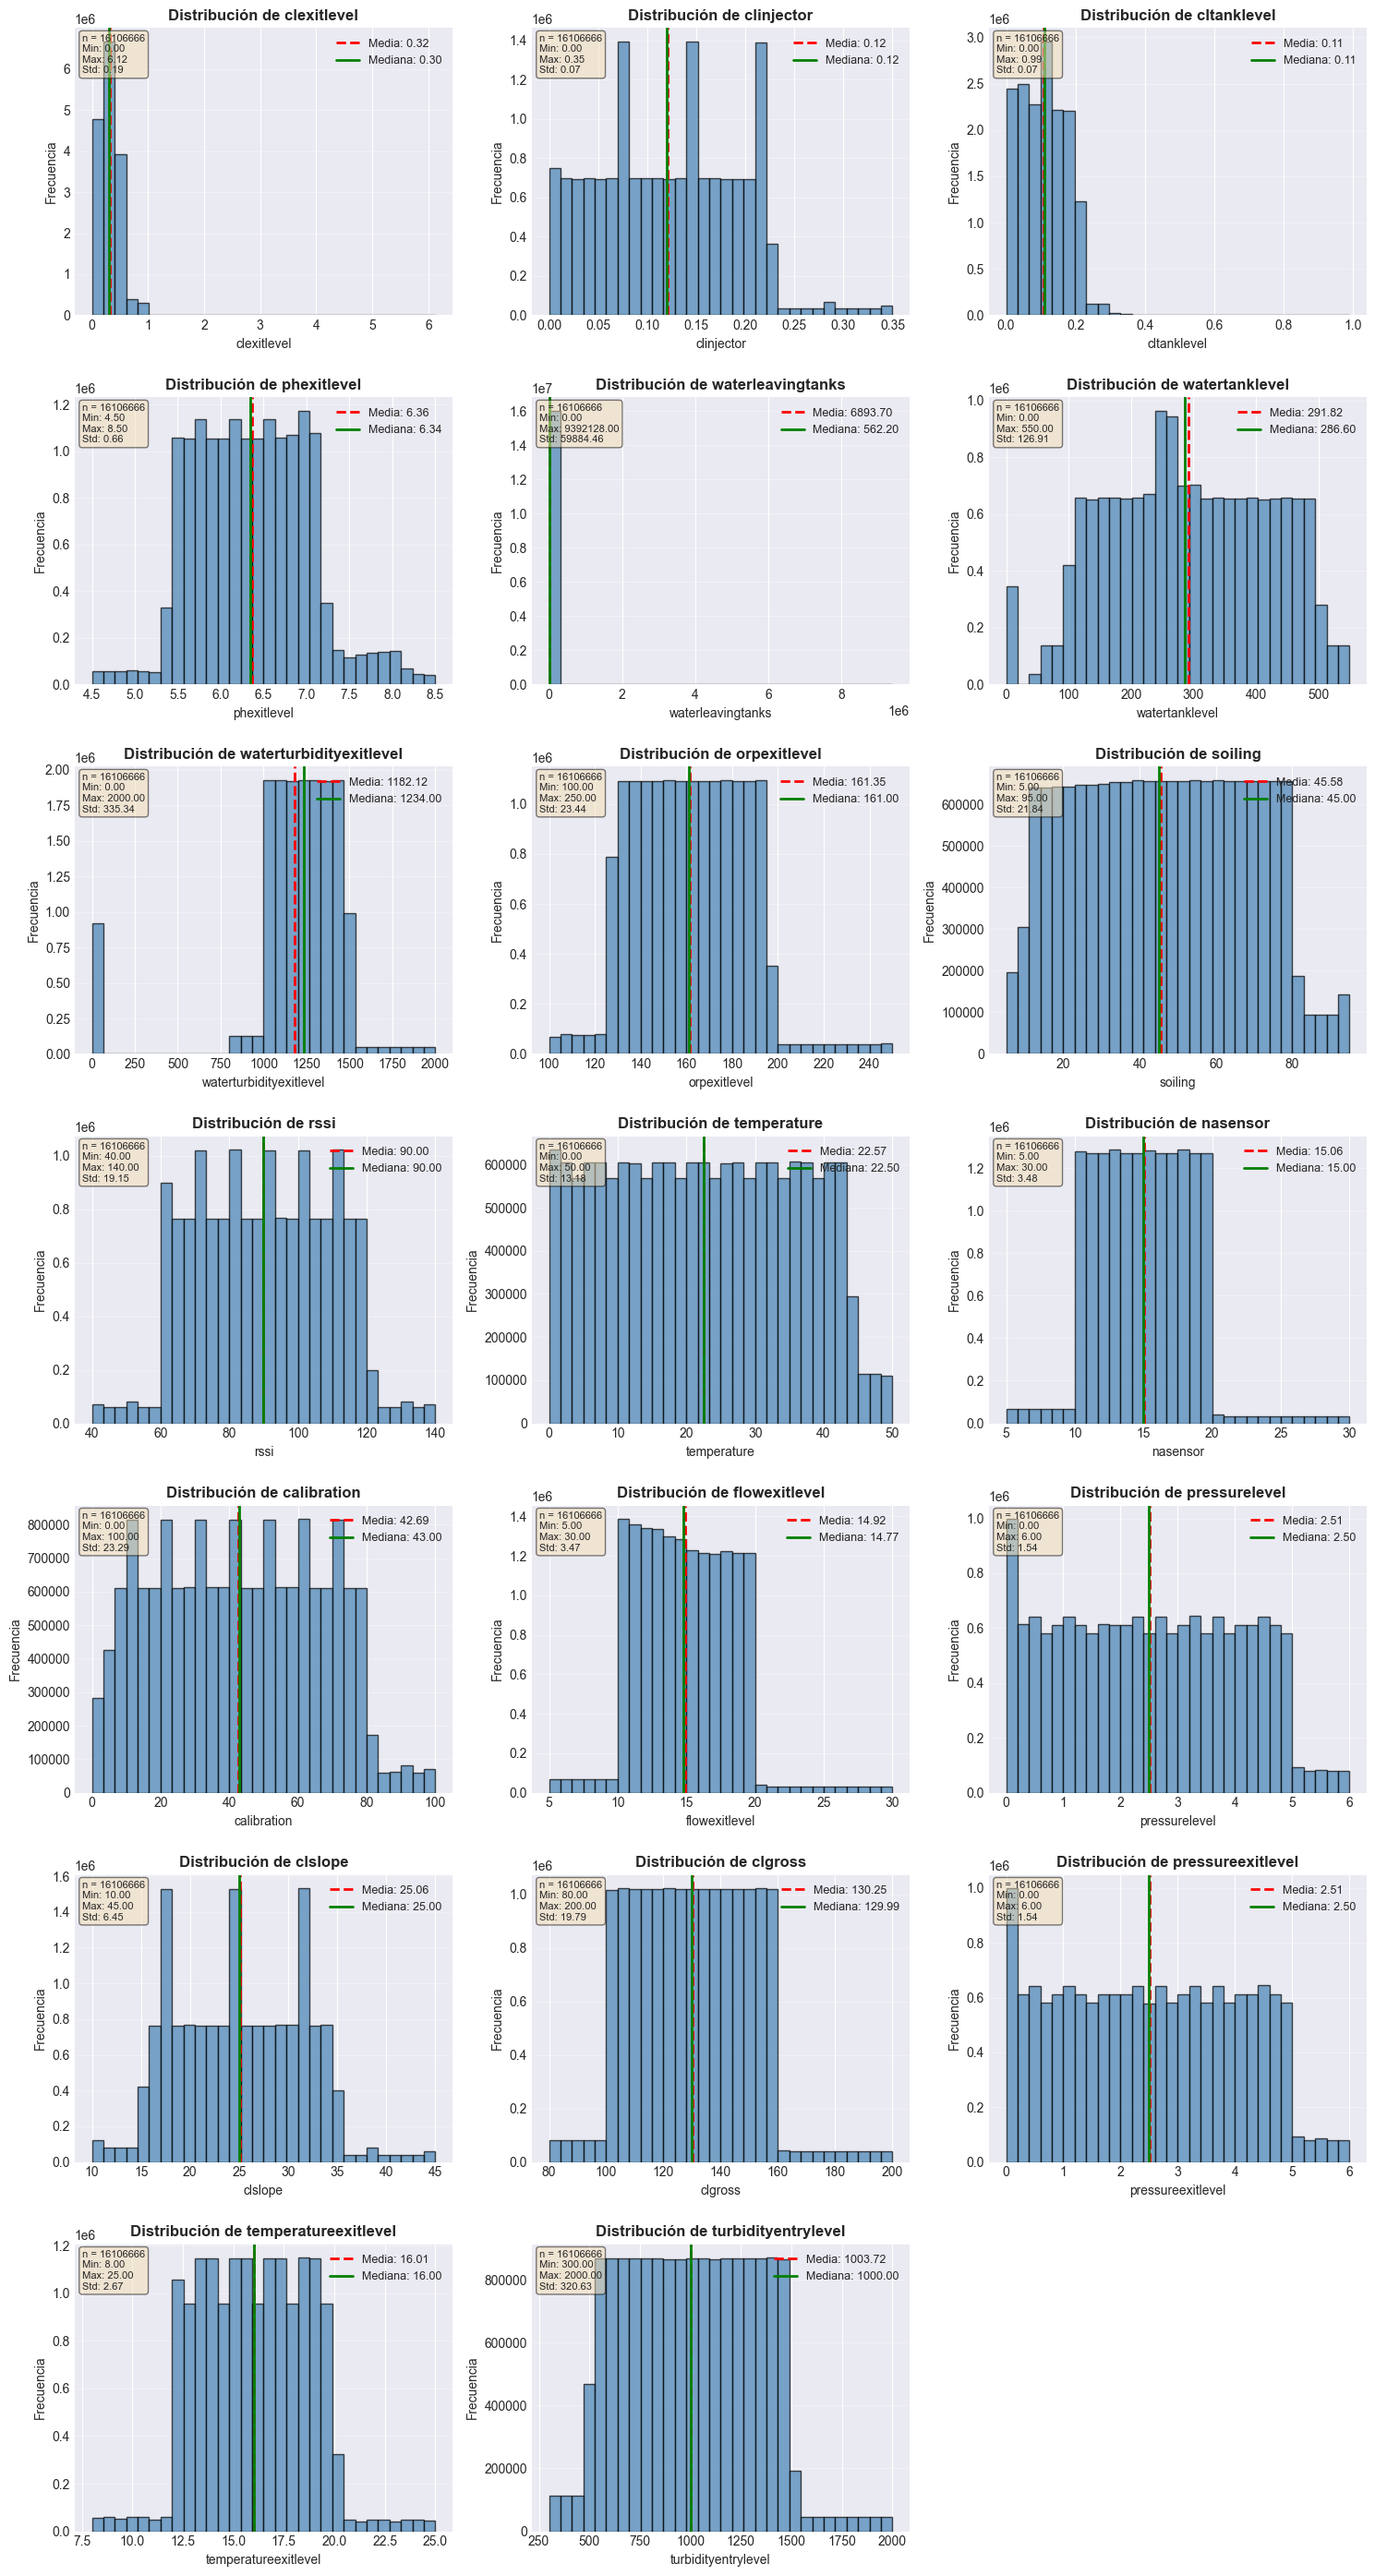

In [25]:
# ============================================================================
# 14. DISTRIBUCIONES DE VARIABLES PRINCIPALES
# ============================================================================

# Hitogramas con estadísticas

print("\n" + "="*80)
print("14. DISTRIBUCIONES DE VARIABLES PRINCIPALES")
print("="*80)

# Seleccionar variables clave para visualización
key_vars = numeric_cols
key_vars = [v for v in key_vars if v in df.columns and df[v].notna().sum() > 0]

if key_vars:
    n_cols = 3
    n_rows = (len(key_vars) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, var in enumerate(key_vars):
        data = df[var].dropna()
        if len(data) > 0:
            # Crear histograma
            axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'Distribución de {var}', fontweight='bold')
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('Frecuencia')
            axes[idx].grid(axis='y', alpha=0.3)
            
            # Calcular estadísticas
            media = data.mean()
            mediana = data.median()
            
            # Añadir líneas verticales para media y mediana
            axes[idx].axvline(media, color='red', linestyle='--', linewidth=2, 
                             label=f'Media: {media:.2f}')
            axes[idx].axvline(mediana, color='green', linestyle='-', linewidth=2, 
                             label=f'Mediana: {mediana:.2f}')
            
            # Añadir leyenda
            axes[idx].legend(loc='upper right', fontsize=9)
            
            # Añadir texto con estadísticas adicionales
            stats_text = f'n = {len(data)}\nMin: {data.min():.2f}\nMax: {data.max():.2f}\nStd: {data.std():.2f}'
            axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                          verticalalignment='top', fontsize=8,
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Ocultar subplots vacíos
    for idx in range(len(key_vars), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Data visualization

Visualización de series temporales agrupadas y por provincia

In [26]:
# ============================================================================
# CONFIGURACIÓN DE VARIABLES
# ============================================================================

# Variables de calidad del agua
calidad_vars = [
    'clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel',
    'waterturbidityexitlevel', 'orpexitlevel', 'soiling', 'rssi',
    'temperature', 'nasensor', 'calibration', 'flowexitlevel',
    'pressurelevel', 'clslope', 'clgross', 'pressureexitlevel',
    'temperatureexitlevel', 'turbidityentrylevel'
]

# Diccionario de unidades y nombres descriptivos
metadata = {
    'watertanklevel': {'unidad': 'cm', 'nombre': 'Nivel del Tanque', 'tipo': 'nivel'},
    'waterleavingtanks': {'unidad': 'm³', 'nombre': 'Agua de Salida', 'tipo': 'nivel'},
    'clexitlevel': {'unidad': 'ppm', 'nombre': 'Cloro Salida', 'tipo': 'calidad'},
    'clinjector': {'unidad': 'ppm', 'nombre': 'Cloro Inyector', 'tipo': 'calidad'},
    'cltanklevel': {'unidad': 'ppm', 'nombre': 'Cloro Tanque', 'tipo': 'calidad'},
    'phexitlevel': {'unidad': 'pH', 'nombre': 'pH Salida', 'tipo': 'calidad'},
    'waterturbidityexitlevel': {'unidad': 'NTU', 'nombre': 'Turbidez Salida', 'tipo': 'calidad'},
    'orpexitlevel': {'unidad': 'mV', 'nombre': 'ORP Salida', 'tipo': 'calidad'},
    'soiling': {'unidad': '%', 'nombre': 'Ensuciamiento', 'tipo': 'calidad'},
    'rssi': {'unidad': 'dBm', 'nombre': 'Señal RSSI', 'tipo': 'calidad'},
    'temperature': {'unidad': '°C', 'nombre': 'Temperatura', 'tipo': 'calidad'},
    'nasensor': {'unidad': 'nA', 'nombre': 'Sensor nA', 'tipo': 'calidad'},
    'calibration': {'unidad': '%', 'nombre': 'Calibración', 'tipo': 'calidad'},
    'flowexitlevel': {'unidad': 'm³/h', 'nombre': 'Flujo Salida', 'tipo': 'calidad'},
    'pressurelevel': {'unidad': 'bar', 'nombre': 'Presión', 'tipo': 'calidad'},
    'clslope': {'unidad': '%', 'nombre': 'Pendiente Cl', 'tipo': 'calidad'},
    'clgross': {'unidad': 'µA', 'nombre': 'Cloro Bruto', 'tipo': 'calidad'},
    'pressureexitlevel': {'unidad': 'bar', 'nombre': 'Presión Salida', 'tipo': 'calidad'},
    'temperatureexitlevel': {'unidad': '°C', 'nombre': 'Temperatura Salida', 'tipo': 'calidad'},
    'turbidityentrylevel': {'unidad': 'NTU', 'nombre': 'Turbidez Entrada', 'tipo': 'calidad'}
}

PREPARACIÓN DE DATOS TEMPORALES
Rango temporal: 2020-05-25 10:21:18+00:00 a 2025-10-07 08:31:37.290000+00:00
Años disponibles: [2020, 2021, 2022, 2023, 2024, 2025]
Meses únicos: 66
Provincias disponibles: ['Ávila', 'Palencia', 'Valladolid', 'Soria', 'Salamanca', 'Burgos', NaN]
Categories (6, object): ['Burgos', 'Palencia', 'Salamanca', 'Soria', 'Valladolid', 'Ávila']

Variables de calidad encontradas: 18 de 18

SECCIÓN 1: ANÁLISIS DE NIVEL DE AGUA

TABLA 1.1: ESTADÍSTICAS DE NIVEL DE AGUA POR PROVINCIA
----------------------------------------------------------------------------------------------------
            Media  Mediana  Desv_Std  Mínimo  Máximo     Q1     Q3  Registros
province                                                                     
Burgos     286.23   300.00     44.24  100.00  300.00 300.00 300.00      44649
Palencia   299.93   300.00    123.39    0.01  550.00 194.70 405.20   14629892
Salamanca  299.89   299.80    123.27   50.00  550.00 194.40 405.00     358472
S

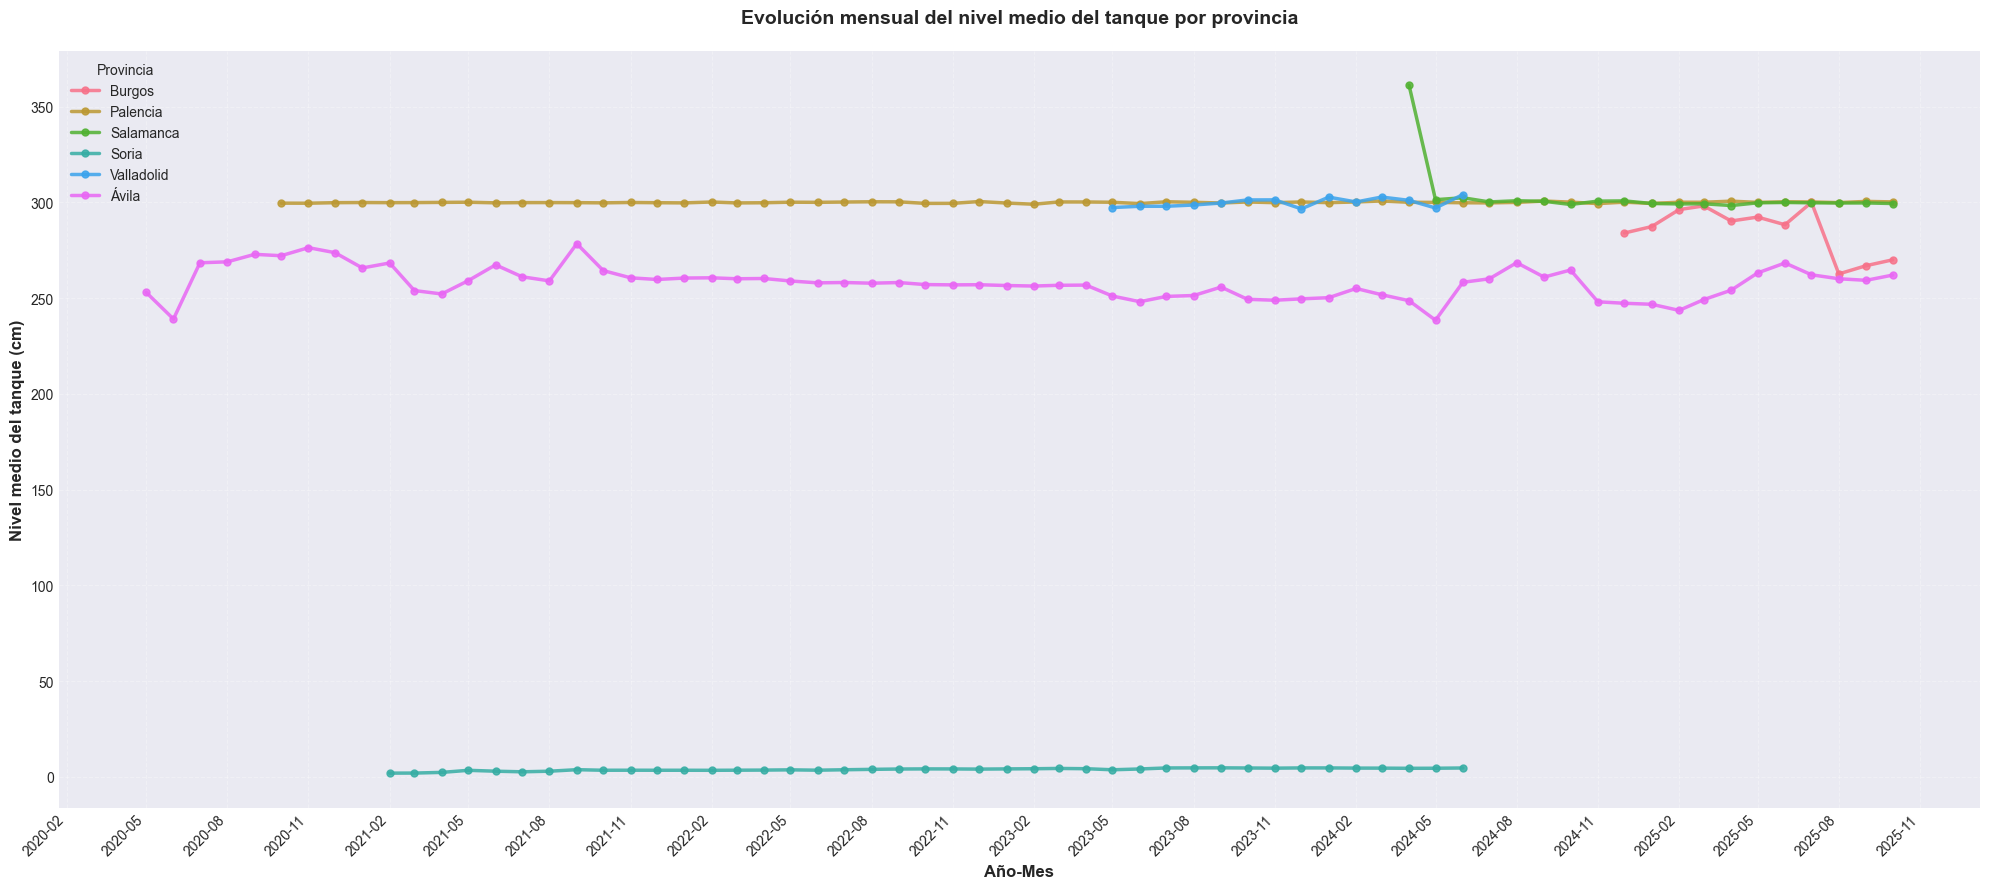

In [27]:
# ============================================================================
# PREPARACIÓN DE DATOS TEMPORALES
# ============================================================================

print("="*100)
print("PREPARACIÓN DE DATOS TEMPORALES")
print("="*100)

df['timeinstant'] = pd.to_datetime(df['timeinstant'])
df['year'] = df['timeinstant'].dt.year
df['month'] = df['timeinstant'].dt.month
df['year_month'] = df['timeinstant'].dt.to_period('M')

print(f"Rango temporal: {df['timeinstant'].min()} a {df['timeinstant'].max()}")
print(f"Años disponibles: {sorted(df['year'].unique())}")
print(f"Meses únicos: {len(df['year_month'].unique())}")
print(f"Provincias disponibles: {df['province'].unique()}")

# Filtrar solo columnas que existen en el DataFrame
calidad_vars_existentes = [col for col in calidad_vars if col in df.columns]
print(f"\nVariables de calidad encontradas: {len(calidad_vars_existentes)} de {len(calidad_vars)}")

# ============================================================================
# SECCIÓN 1: ANÁLISIS DE NIVEL DE AGUA (WATERTANKLEVEL)
# ============================================================================

print("\n" + "="*100)
print("SECCIÓN 1: ANÁLISIS DE NIVEL DE AGUA")
print("="*100)

# Tabla 1.1: Estadísticas por provincia - Nivel de agua
print("\nTABLA 1.1: ESTADÍSTICAS DE NIVEL DE AGUA POR PROVINCIA")
print("-"*100)

estadisticas_nivel = df.groupby('province')['watertanklevel'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desv_Std', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Registros', 'count')
]).round(2)

print(estadisticas_nivel)

# Tabla 1.2: Cumplimiento de umbrales
print("\n" + "-"*100)
print("TABLA 1.2: CUMPLIMIENTO DE UMBRALES DE NIVEL")
print("-"*100)

cumplimiento_nivel = []
for province in df['province'].unique():
    data_prov = df[df['province'] == province]
    total = len(data_prov)
    
    min_threshold = 100 #data_prov['watertanklevelminthreshold'].iloc[0] if 'watertanklevelminthreshold' in df.columns else None
    max_threshold = 500 #data_prov['watertanklevelmaxthreshold'].iloc[0] if 'watertanklevelmaxthreshold' in df.columns else None
    
    if min_threshold is not None and max_threshold is not None:
        below_min = (data_prov['watertanklevel'] < min_threshold).sum()
        in_range = ((data_prov['watertanklevel'] >= min_threshold) & 
                    (data_prov['watertanklevel'] <= max_threshold)).sum()
        above_max = (data_prov['watertanklevel'] > max_threshold).sum()
        
        cumplimiento_nivel.append({
            'Provincia': province,
            'Umbral_Min': min_threshold,
            'Umbral_Max': max_threshold,
            'Bajo_Mínimo': below_min,
            '%_Bajo': round(below_min/total*100, 2),
            'En_Rango': in_range,
            '%_Rango': round(in_range/total*100, 2),
            'Sobre_Máximo': above_max,
            '%_Sobre': round(above_max/total*100, 2)
        })

df_cumplimiento_nivel = pd.DataFrame(cumplimiento_nivel)
print(df_cumplimiento_nivel.to_string(index=False))

# Gráfico 1: Evolución temporal del nivel por provincia
print("\nGenerando Gráfico 1: Evolución temporal del nivel de agua...")

media_nivel_mes = df.groupby(['province', 'year_month']).agg({
    'watertanklevel': 'mean'
}).reset_index()
media_nivel_mes['date'] = media_nivel_mes['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(20, 9))

for province in media_nivel_mes['province'].unique():
    data_province = media_nivel_mes[media_nivel_mes['province'] == province]
    ax.plot(data_province['date'], data_province['watertanklevel'], 
            marker='o', linewidth=2.5, label=province, markersize=5, alpha=0.85)

ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_xlabel('Año-Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Nivel medio del tanque (cm)', fontsize=12, fontweight='bold')
ax.set_title('Evolución mensual del nivel medio del tanque por provincia', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Provincia', fontsize=10, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


SECCIÓN 2: ANÁLISIS DE CALIDAD DEL AGUA

TABLA 2.1: ESTADÍSTICAS GLOBALES DE CALIDAD DEL AGUA
----------------------------------------------------------------------------------------------------
          Variable Unidad   Media  Mediana  Desv_Std  Mínimo  Máximo  Registros  %_Nulos
      Cloro Salida    ppm    0.32     0.30      0.19    0.00    6.12   16106666     0.00
    Cloro Inyector    ppm    0.12     0.12      0.07    0.00    0.35   16106666     0.00
      Cloro Tanque    ppm    0.11     0.11      0.07    0.00    0.99   16106666     0.00
         pH Salida     pH    6.36     6.34      0.66    4.50    8.50   16106666     0.00
   Turbidez Salida    NTU 1182.12  1234.00    335.34    0.00 2000.00   16106666     0.00
        ORP Salida     mV  161.35   161.00     23.44  100.00  250.00   16106666     0.00
     Ensuciamiento      %   45.58    45.00     21.84    5.00   95.00   16106666     0.00
        Señal RSSI    dBm   90.00    90.00     19.15   40.00  140.00   16106666     0.00
   

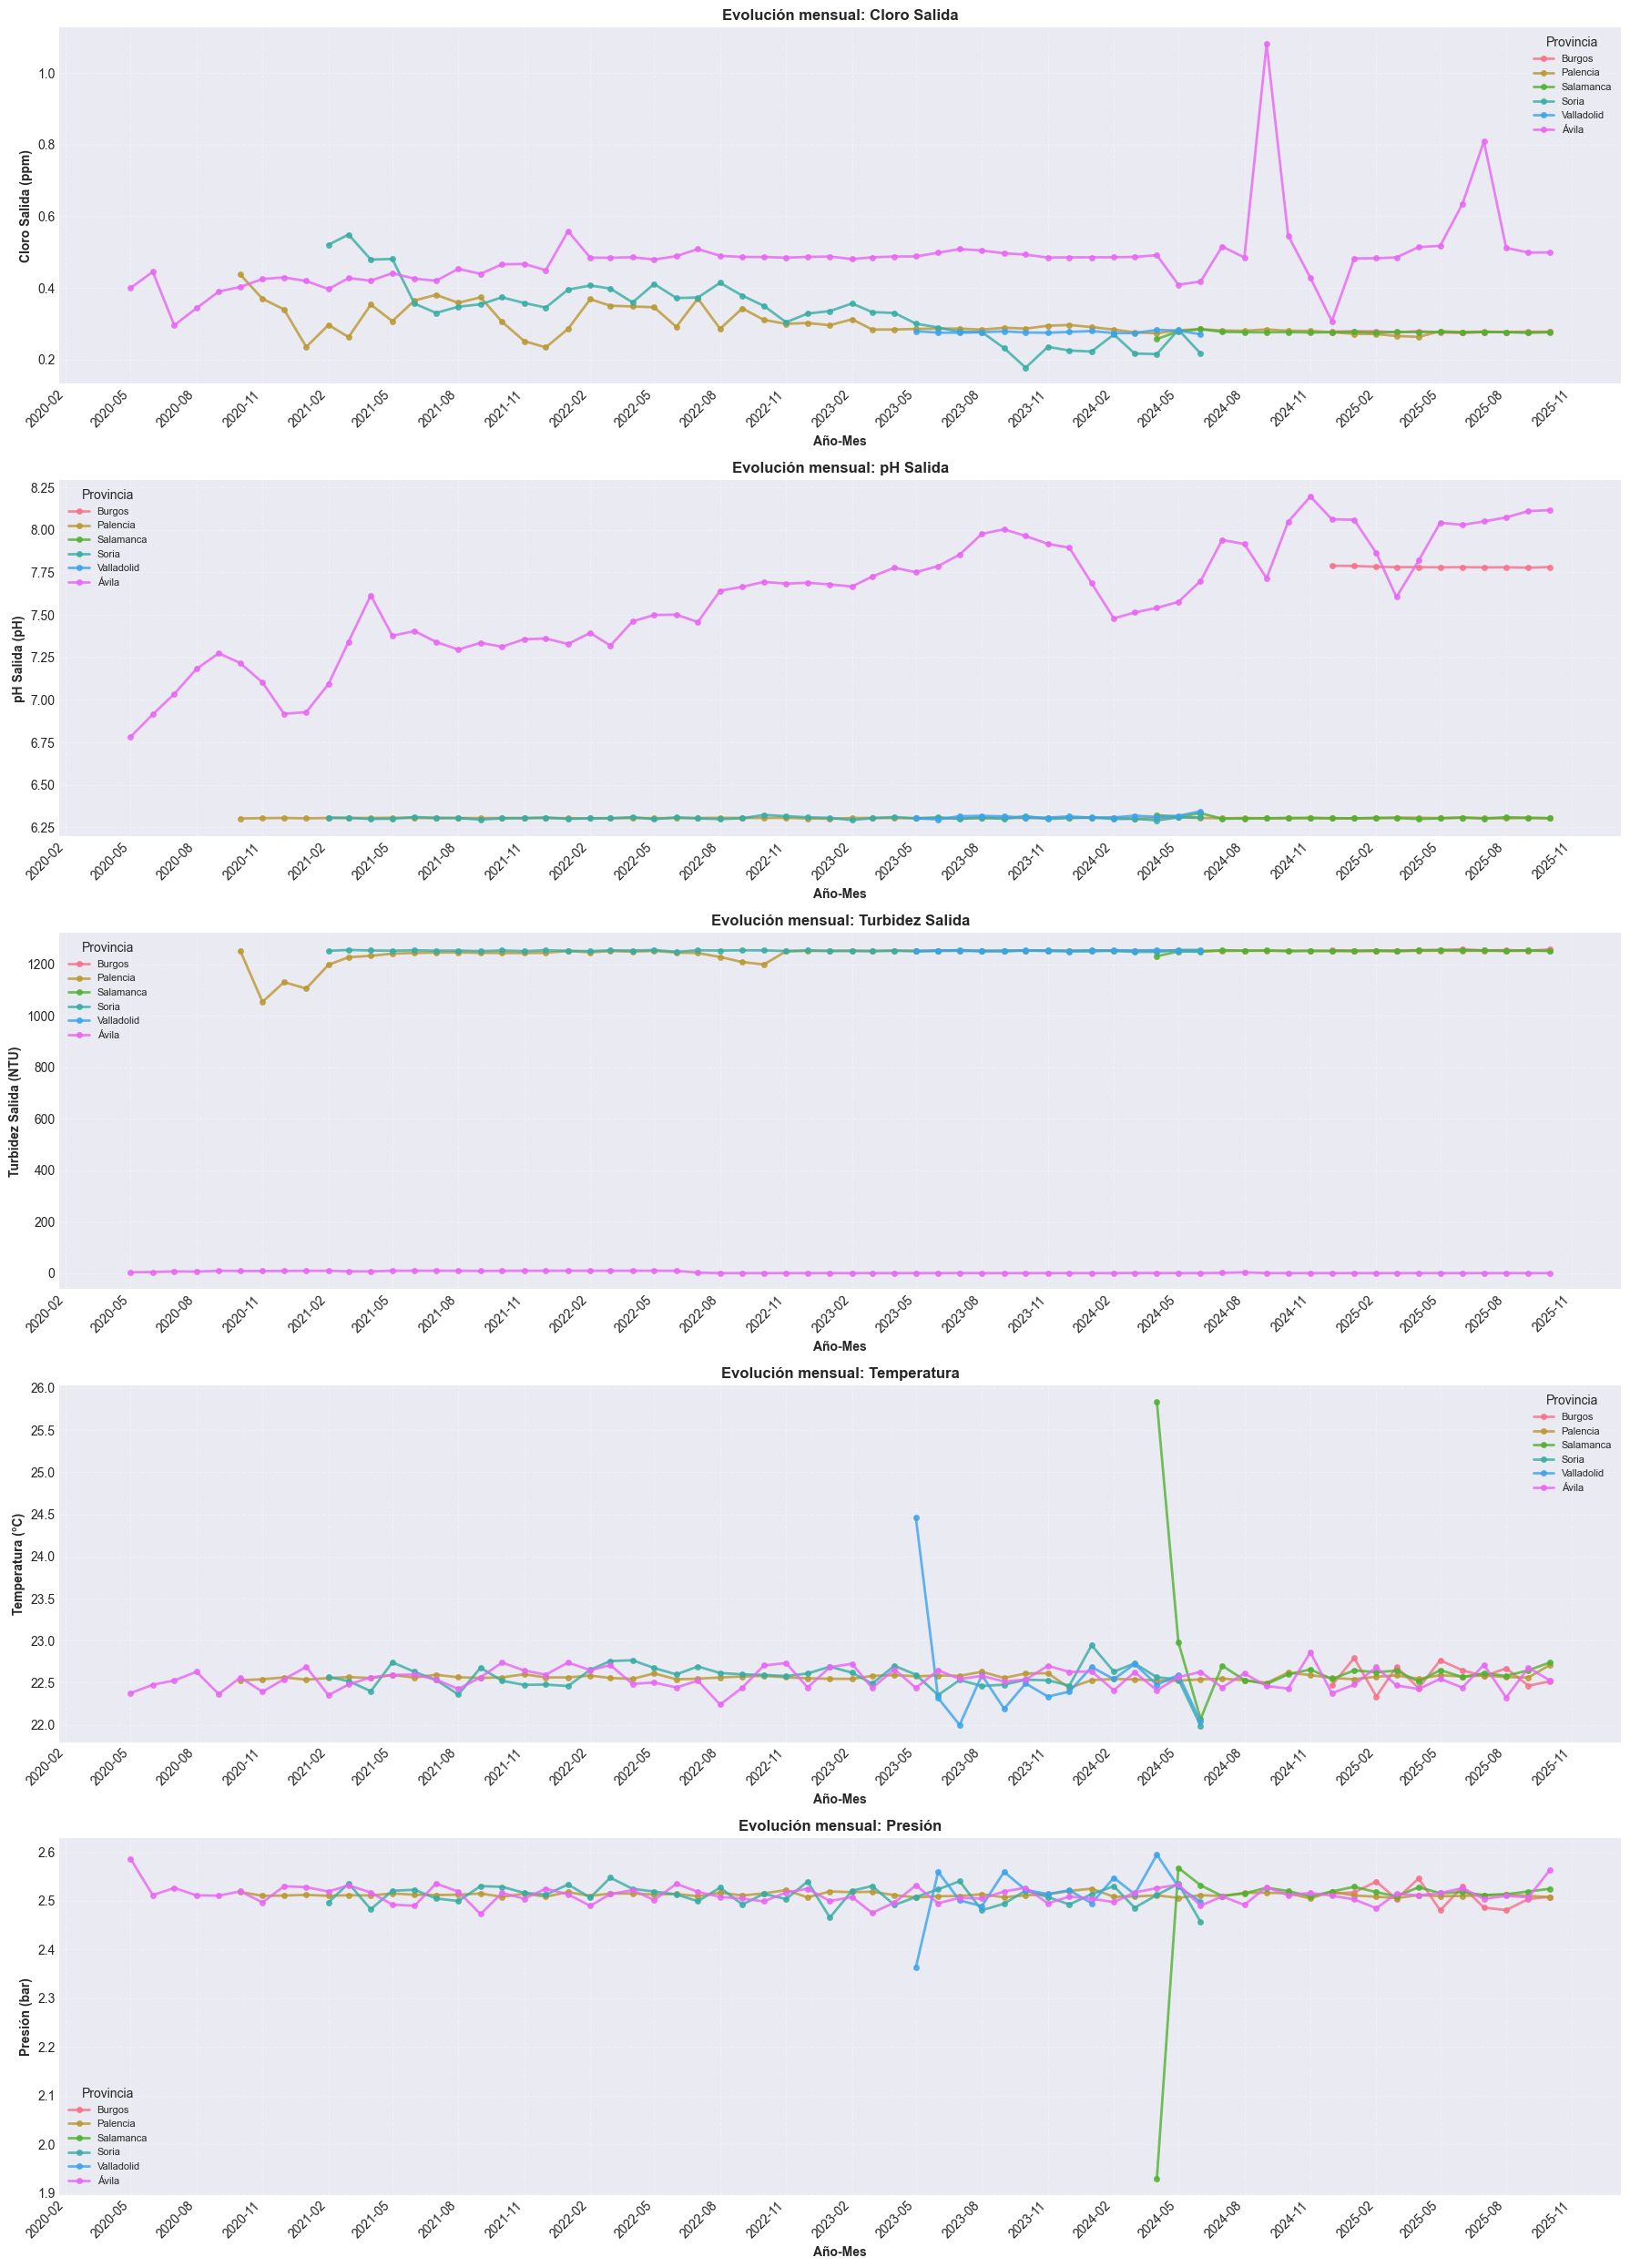


Generando Gráfico 3: Correlaciones entre variables de calidad...


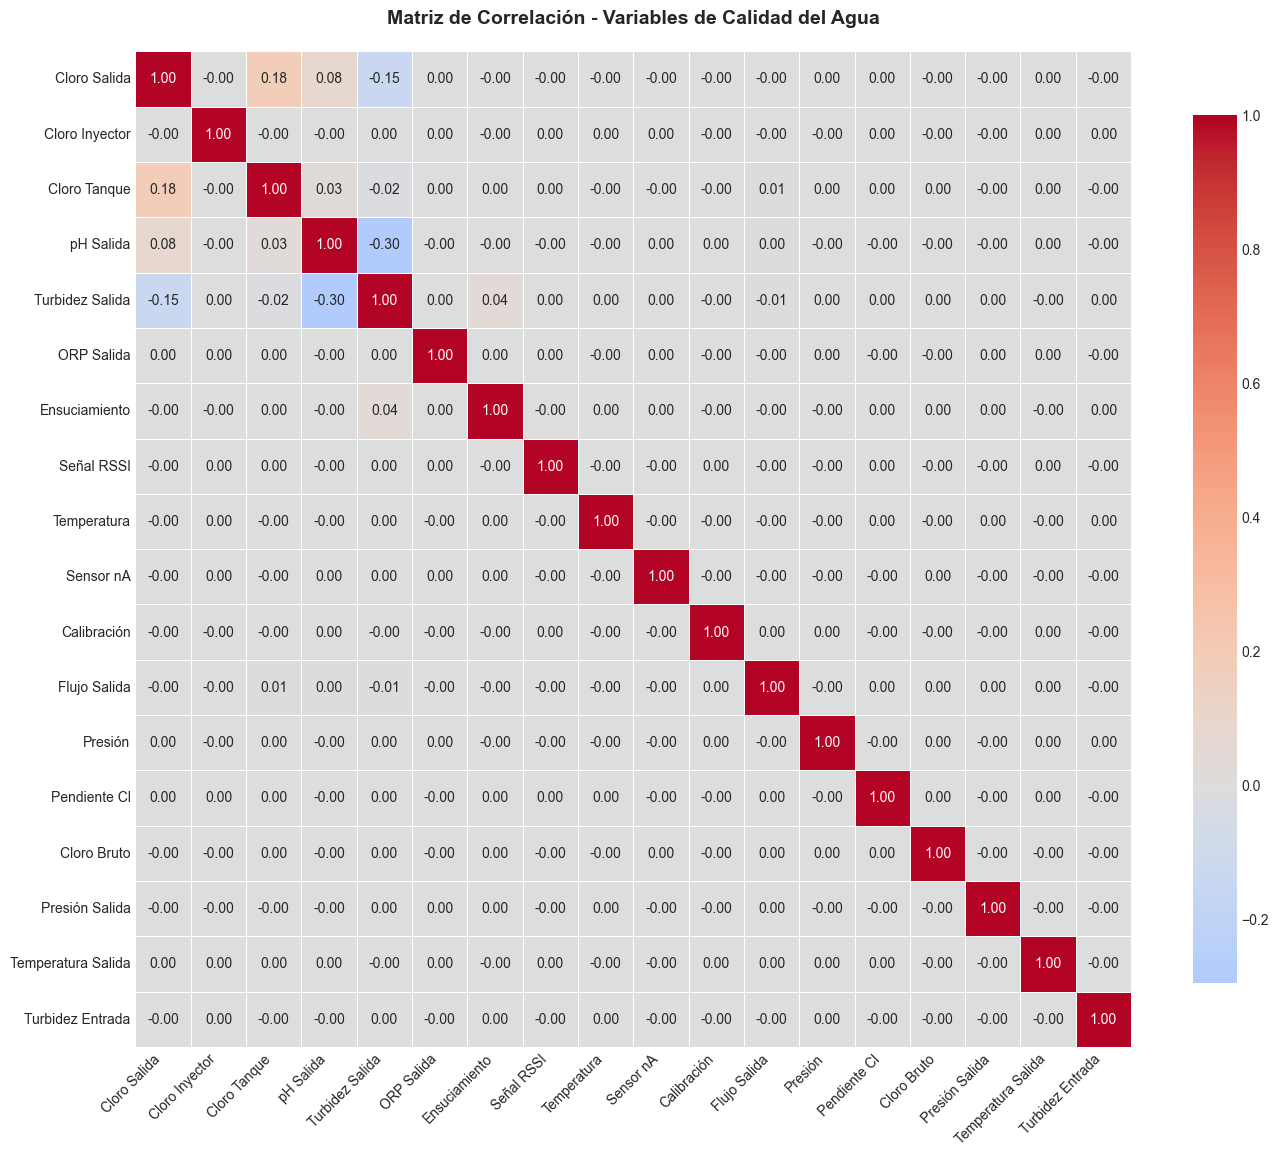

In [28]:
# ============================================================================
# SECCIÓN 2: ANÁLISIS DE CALIDAD DEL AGUA
# ============================================================================

print("\n" + "="*100)
print("SECCIÓN 2: ANÁLISIS DE CALIDAD DEL AGUA")
print("="*100)

# Tabla 2.1: Estadísticas globales de calidad
print("\nTABLA 2.1: ESTADÍSTICAS GLOBALES DE CALIDAD DEL AGUA")
print("-"*100)

estadisticas_calidad_global = []
for var in calidad_vars_existentes:
    if var in df.columns:
        data = df[var].dropna()
        if len(data) > 0:
            meta = metadata.get(var, {'unidad': '-', 'nombre': var})
            estadisticas_calidad_global.append({
                'Variable': meta['nombre'],
                'Unidad': meta['unidad'],
                'Media': round(data.mean(), 2),
                'Mediana': round(data.median(), 2),
                'Desv_Std': round(data.std(), 2),
                'Mínimo': round(data.min(), 2),
                'Máximo': round(data.max(), 2),
                'Registros': len(data),
                '%_Nulos': round(df[var].isnull().sum() / len(df) * 100, 2)
            })

df_calidad_global = pd.DataFrame(estadisticas_calidad_global)
print(df_calidad_global.to_string(index=False))

# Tabla 2.2: Estadísticas de calidad por provincia
print("\n" + "-"*100)
print("TABLA 2.2: ESTADÍSTICAS DE CALIDAD POR PROVINCIA (Variables Clave)")
print("-"*100)

# Variables clave para análisis por provincia
vars_clave = ['clexitlevel', 'phexitlevel', 'waterturbidityexitlevel', 
              'temperature', 'pressurelevel']
vars_clave_existentes = [v for v in vars_clave if v in df.columns]

for var in vars_clave_existentes:
    meta = metadata.get(var, {'unidad': '-', 'nombre': var})
    print(f"\n{meta['nombre']} ({meta['unidad']}):")
    print("-" * 80)
    
    stats = df.groupby('province')[var].agg([
        ('Media', 'mean'),
        ('Mediana', 'median'),
        ('Desv_Std', 'std'),
        ('Mínimo', 'min'),
        ('Máximo', 'max')
    ]).round(2)
    print(stats)

# Gráfico 2: Evolución temporal de variables clave de calidad
print("\nGenerando Gráfico 2: Evolución temporal de calidad del agua...")

n_vars = len(vars_clave_existentes)
if n_vars > 0:
    fig, axes = plt.subplots(n_vars, 1, figsize=(18, 5*n_vars))
    if n_vars == 1:
        axes = [axes]
    
    for idx, var in enumerate(vars_clave_existentes):
        meta = metadata.get(var, {'unidad': '-', 'nombre': var})
        
        media_var_mes = df.groupby(['province', 'year_month']).agg({
            var: 'mean'
        }).reset_index()
        media_var_mes['date'] = media_var_mes['year_month'].dt.to_timestamp()
        
        for province in media_var_mes['province'].unique():
            data_province = media_var_mes[media_var_mes['province'] == province]
            axes[idx].plot(data_province['date'], data_province[var], 
                          marker='o', linewidth=2, label=province, markersize=4, alpha=0.8)
        
        axes[idx].xaxis.set_major_formatter(DateFormatter('%Y-%m'))
        axes[idx].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        axes[idx].set_xlabel('Año-Mes', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel(f'{meta["nombre"]} ({meta["unidad"]})', fontsize=10, fontweight='bold')
        axes[idx].set_title(f'Evolución mensual: {meta["nombre"]}', fontsize=12, fontweight='bold')
        axes[idx].legend(title='Provincia', fontsize=8, loc='best')
        axes[idx].grid(True, alpha=0.3, linestyle='--')
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Gráfico 3: Heatmap de correlaciones entre variables de calidad
print("\nGenerando Gráfico 3: Correlaciones entre variables de calidad...")

if len(calidad_vars_existentes) > 1:
    # Calcular correlaciones
    corr_matrix = df[calidad_vars_existentes].corr()
    
    # Crear heatmap
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Usar nombres descriptivos
    nombres_cortos = [metadata.get(v, {'nombre': v})['nombre'] for v in calidad_vars_existentes]
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=nombres_cortos, yticklabels=nombres_cortos,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    
    ax.set_title('Matriz de Correlación - Variables de Calidad del Agua', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [29]:
# ============================================================================
# SECCIÓN 3: RANKING DE MESES MÁS CRÍTICOS DEL NIVEL DEL AGUA DE LOS TANQUES
# ============================================================================

print("\n" + "="*100)
print("SECCIÓN 3: RANKING DE MESES MÁS CRÍTICOS")
print("="*100)

# 3.1 Meses críticos por nivel de agua
print("\nTABLA 3.1: TOP 5 MESES - NIVEL DE AGUA")
print("-"*100)

media_nivel_mes = df.groupby(['province', 'year_month']).agg({
    'watertanklevel': 'mean'
}).reset_index()

print("\n--- NIVELES MÁS BAJOS ---")
for province in df['province'].unique():
    data_prov = media_nivel_mes[media_nivel_mes['province'] == province]
    top_bajos = data_prov.nsmallest(5, 'watertanklevel')
    print(f"\n{province}:")
    for idx, row in enumerate(top_bajos.itertuples(), 1):
        print(f"  {idx}. {row.year_month}: {row.watertanklevel:.2f} cm")

print("\n--- NIVELES MÁS ALTOS ---")
for province in df['province'].unique():
    data_prov = media_nivel_mes[media_nivel_mes['province'] == province]
    top_altos = data_prov.nlargest(5, 'watertanklevel')
    print(f"\n{province}:")
    for idx, row in enumerate(top_altos.itertuples(), 1):
        print(f"  {idx}. {row.year_month}: {row.watertanklevel:.2f} cm")

# 3.2 Meses críticos por calidad del agua (variables clave)
print("\n" + "-"*100)
print("TABLA 3.2: TOP 5 MESES - CALIDAD DEL AGUA (Variables Clave)")
print("-"*100)

for var in vars_clave_existentes[:3]:  # Mostrar solo las 3 primeras variables clave
    meta = metadata.get(var, {'unidad': '-', 'nombre': var})
    print(f"\n{'='*80}")
    print(f"{meta['nombre']} ({meta['unidad']})")
    print('='*80)
    
    media_var_mes = df.groupby(['province', 'year_month']).agg({
        var: 'mean'
    }).reset_index()
    
    print("\n--- VALORES MÁS BAJOS ---")
    for province in df['province'].unique():
        data_prov = media_var_mes[media_var_mes['province'] == province]
        top_bajos = data_prov.nsmallest(5, var)
        print(f"\n{province}:")
        for idx, row in enumerate(top_bajos.itertuples(), 1):
            print(f"  {idx}. {getattr(row, 'year_month')}: {getattr(row, var):.2f} {meta['unidad']}")
    
    print("\n--- VALORES MÁS ALTOS ---")
    for province in df['province'].unique():
        data_prov = media_var_mes[media_var_mes['province'] == province]
        top_altos = data_prov.nlargest(5, var)
        print(f"\n{province}:")
        for idx, row in enumerate(top_altos.itertuples(), 1):
            print(f"  {idx}. {getattr(row, 'year_month')}: {getattr(row, var):.2f} {meta['unidad']}")



SECCIÓN 3: RANKING DE MESES MÁS CRÍTICOS

TABLA 3.1: TOP 5 MESES - NIVEL DE AGUA
----------------------------------------------------------------------------------------------------

--- NIVELES MÁS BAJOS ---

Ávila:
  1. 2024-05: 238.48 cm
  2. 2020-06: 239.10 cm
  3. 2025-02: 243.59 cm
  4. 2025-01: 246.78 cm
  5. 2024-12: 247.31 cm

Palencia:
  1. 2023-02: 299.01 cm
  2. 2023-06: 299.34 cm
  3. 2024-11: 299.36 cm
  4. 2025-01: 299.43 cm
  5. 2022-10: 299.46 cm

Valladolid:
  1. 2023-12: 296.58 cm
  2. 2024-05: 297.07 cm
  3. 2023-05: 297.29 cm
  4. 2023-06: 297.95 cm
  5. 2023-07: 297.95 cm

Soria:
  1. 2021-02: 2.00 cm
  2. 2021-03: 2.03 cm
  3. 2021-04: 2.38 cm
  4. 2021-07: 2.69 cm
  5. 2021-08: 3.01 cm

Salamanca:
  1. 2025-04: 298.34 cm
  2. 2024-10: 298.89 cm
  3. 2025-02: 299.17 cm
  4. 2025-03: 299.26 cm
  5. 2025-10: 299.40 cm

Burgos:
  1. 2025-08: 262.64 cm
  2. 2025-09: 266.95 cm
  3. 2025-10: 270.00 cm
  4. 2024-12: 283.99 cm
  5. 2025-01: 287.35 cm

nan:

--- NIVELES 

In [30]:
# ============================================================================
# SECCIÓN 4: VARIABILIDAD POR PROVINCIA
# ============================================================================

print("\n" + "="*100)
print("SECCIÓN 4: VARIABILIDAD Y ESTABILIDAD POR PROVINCIA")
print("="*100)

# 4.1 Variabilidad del nivel de agua
print("\nTABLA 4.1: VARIABILIDAD DEL NIVEL DE AGUA")
print("-"*100)

variabilidad_nivel = []
for province in df['province'].unique():
    data_prov = df[df['province'] == province]
    
    media = data_prov['watertanklevel'].mean()
    desv_std = data_prov['watertanklevel'].std()
    cv = (desv_std / media * 100) if media != 0 else 0
    
    q1 = data_prov['watertanklevel'].quantile(0.25)
    q3 = data_prov['watertanklevel'].quantile(0.75)
    iqr = q3 - q1
    
    # Cambios bruscos (>50 cm)
    data_sorted = data_prov.sort_values('timeinstant')
    cambios = data_sorted['watertanklevel'].diff().abs()
    cambios_bruscos = (cambios > 50).sum()
    
    variabilidad_nivel.append({
        'Provincia': province,
        'Media': round(media, 2),
        'Desv_Std': round(desv_std, 2),
        'CV_%': round(cv, 2),
        'IQR': round(iqr, 2),
        'Rango': round(data_prov['watertanklevel'].max() - data_prov['watertanklevel'].min(), 2),
        'Cambios_Bruscos': cambios_bruscos
    })

df_var_nivel = pd.DataFrame(variabilidad_nivel).sort_values('CV_%', ascending=False)
print(df_var_nivel.to_string(index=False))

print("\nInterpretación CV%:")
print("  - CV% < 10: Muy estable")
print("  - CV% 10-20: Estabilidad moderada")
print("  - CV% > 20: Alta variabilidad")

# 4.2 Variabilidad de calidad del agua
print("\n" + "-"*100)
print("TABLA 4.2: VARIABILIDAD DE CALIDAD DEL AGUA POR PROVINCIA")
print("-"*100)

for var in vars_clave_existentes:
    meta = metadata.get(var, {'unidad': '-', 'nombre': var})
    print(f"\n{meta['nombre']} ({meta['unidad']}):")
    print("-" * 80)
    
    variabilidad_var = []
    for province in df['province'].unique():
        data_prov = df[df['province'] == province][var].dropna()
        
        if len(data_prov) > 0:
            media = data_prov.mean()
            desv_std = data_prov.std()
            cv = (desv_std / media * 100) if media != 0 else 0
            
            variabilidad_var.append({
                'Provincia': province,
                'Media': round(media, 2),
                'Desv_Std': round(desv_std, 2),
                'CV_%': round(cv, 2),
                'Rango': round(data_prov.max() - data_prov.min(), 2)
            })
    
    df_var = pd.DataFrame(variabilidad_var).sort_values('CV_%', ascending=False)
    print(df_var.to_string(index=False))


SECCIÓN 4: VARIABILIDAD Y ESTABILIDAD POR PROVINCIA

TABLA 4.1: VARIABILIDAD DEL NIVEL DE AGUA
----------------------------------------------------------------------------------------------------
 Provincia  Media  Desv_Std  CV_%    IQR  Rango  Cambios_Bruscos
     Soria   3.95      3.33 84.11   1.38  10.20                0
Valladolid 299.85    123.52 41.19 210.38 499.90            25620
  Palencia 299.93    123.39 41.14 210.50 549.99         11429707
 Salamanca 299.89    123.27 41.11 210.60 500.00           279772
    Burgos 286.23     44.24 15.46   0.00 200.00             7952
     Ávila 257.70     14.18  5.50  15.00 267.00                2
       NaN    NaN       NaN   NaN    NaN    NaN                0

Interpretación CV%:
  - CV% < 10: Muy estable
  - CV% 10-20: Estabilidad moderada
  - CV% > 20: Alta variabilidad

----------------------------------------------------------------------------------------------------
TABLA 4.2: VARIABILIDAD DE CALIDAD DEL AGUA POR PROVINCIA
--------


SECCIÓN 5: RESUMEN COMPARATIVO GLOBAL

TABLA 5.1: RESUMEN GLOBAL - NIVEL DE AGUA
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
TABLA 5.2: RESUMEN GLOBAL - CALIDAD DEL AGUA
----------------------------------------------------------------------------------------------------
          Variable Unidad Registros_Válidos %_Cobertura Media_Global Mediana_Global Desv_Std_Global
      Cloro Salida    ppm        16,106,666     100.00%         0.32           0.30            0.19
    Cloro Inyector    ppm        16,106,666     100.00%         0.12           0.12            0.07
      Cloro Tanque    ppm        16,106,666     100.00%         0.11           0.11            0.07
         pH Salida     pH        16,106,666     100.00%         6.36           6.34            0.66
   Turbidez Salida    NTU        16,106,666     100.00%      1182.12 

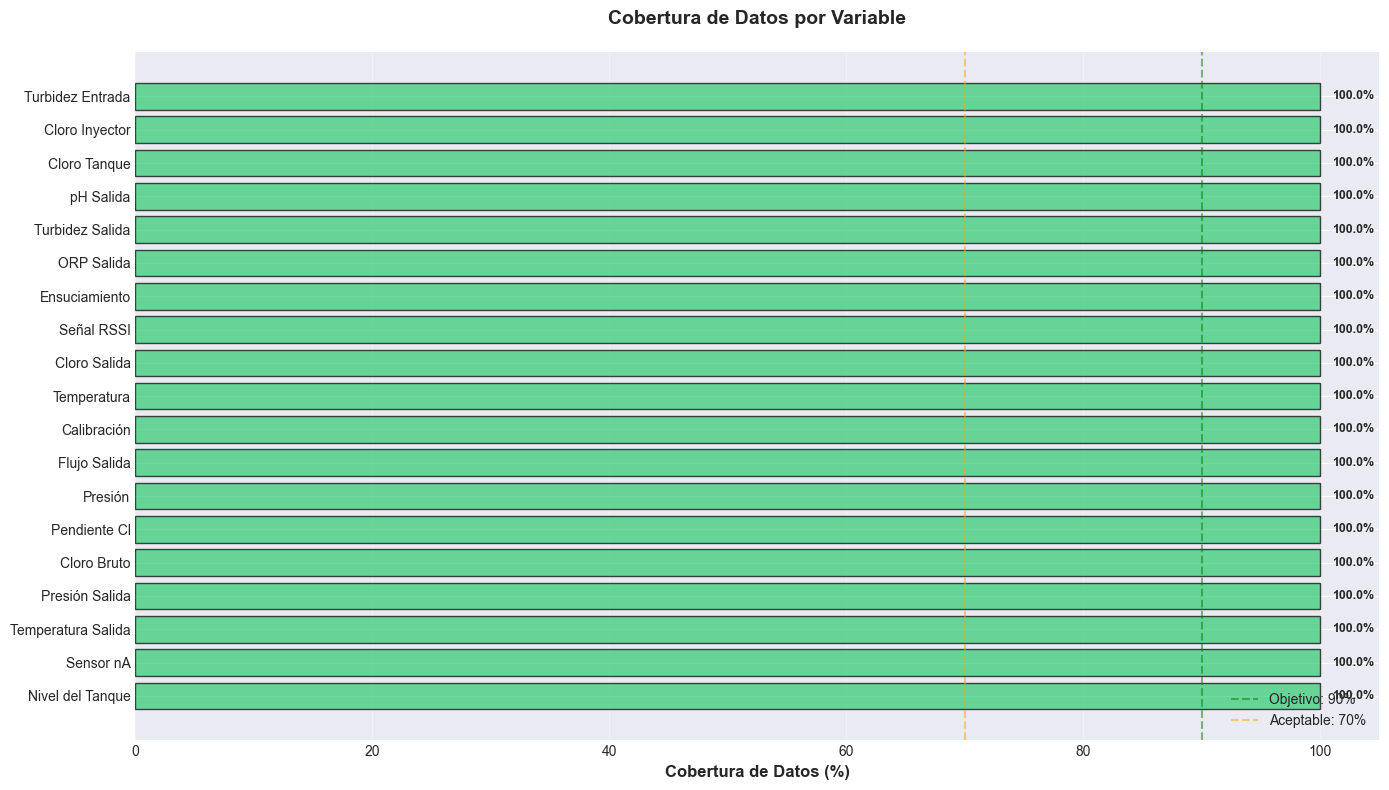


FIN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)

✅ Análisis completo de nivel de agua y calidad del agua finalizado
📊 Gráficos generados: 4
📋 Tablas generadas: 11


In [31]:
# ============================================================================
# SECCIÓN 5: RESUMEN COMPARATIVO GLOBAL
# ============================================================================

print("\n" + "="*100)
print("SECCIÓN 5: RESUMEN COMPARATIVO GLOBAL")
print("="*100)

# 5.1 Resumen de nivel de agua
print("\nTABLA 5.1: RESUMEN GLOBAL - NIVEL DE AGUA")
print("-"*100)

if 'watertanklevelminthreshold' in df.columns and 'watertanklevelmaxthreshold' in df.columns:
    bajo_min = (df['watertanklevel'] < df['watertanklevelminthreshold']).sum()
    en_rango = ((df['watertanklevel'] >= df['watertanklevelminthreshold']) & 
                (df['watertanklevel'] <= df['watertanklevelmaxthreshold'])).sum()
    sobre_max = (df['watertanklevel'] > df['watertanklevelmaxthreshold']).sum()
    
    resumen_nivel = pd.DataFrame({
        'Métrica': [
            'Total Provincias',
            'Total Tanques',
            'Total Registros',
            'Nivel Medio Global',
            'Nivel Mínimo Global',
            'Nivel Máximo Global',
            'Umbral Mínimo',
            'Umbral Máximo',
            'Registros Bajo Mínimo',
            'Registros En Rango',
            'Registros Sobre Máximo',
            '% Cumplimiento'
        ],
        'Valor': [
            df['province'].nunique(),
            df['entityid'].nunique(),
            f"{len(df):,}",
            f"{df['watertanklevel'].mean():.2f} cm",
            f"{df['watertanklevel'].min():.2f} cm",
            f"{df['watertanklevel'].max():.2f} cm",
            f"{df['watertanklevelminthreshold'].iloc[0]:.0f} cm",
            f"{df['watertanklevelmaxthreshold'].iloc[0]:.0f} cm",
            f"{bajo_min:,} ({bajo_min/len(df)*100:.2f}%)",
            f"{en_rango:,} ({en_rango/len(df)*100:.2f}%)",
            f"{sobre_max:,} ({sobre_max/len(df)*100:.2f}%)",
            f"{en_rango / len(df) * 100:.2f}%"
        ]
    })
    
    print(resumen_nivel.to_string(index=False))

# 5.2 Resumen de calidad del agua
print("\n" + "-"*100)
print("TABLA 5.2: RESUMEN GLOBAL - CALIDAD DEL AGUA")
print("-"*100)

resumen_calidad = []
for var in calidad_vars_existentes:
    data = df[var].dropna()
    meta = metadata.get(var, {'unidad': '-', 'nombre': var})
    
    if len(data) > 0:
        resumen_calidad.append({
            'Variable': meta['nombre'],
            'Unidad': meta['unidad'],
            'Registros_Válidos': f"{len(data):,}",
            '%_Cobertura': f"{len(data)/len(df)*100:.2f}%",
            'Media_Global': f"{data.mean():.2f}",
            'Mediana_Global': f"{data.median():.2f}",
            'Desv_Std_Global': f"{data.std():.2f}"
        })

df_resumen_calidad = pd.DataFrame(resumen_calidad)
print(df_resumen_calidad.to_string(index=False))

# 5.3 Comparativa de cobertura de datos
print("\n" + "-"*100)
print("TABLA 5.3: COBERTURA DE DATOS POR VARIABLE")
print("-"*100)

cobertura = []
todas_vars = ['watertanklevel'] + calidad_vars_existentes

for var in todas_vars:
    if var in df.columns:
        total = len(df)
        validos = df[var].notna().sum()
        nulos = df[var].isna().sum()
        
        meta = metadata.get(var, {'unidad': '-', 'nombre': var})
        
        cobertura.append({
            'Variable': meta['nombre'],
            'Total_Registros': total,
            'Registros_Válidos': validos,
            'Registros_Nulos': nulos,
            '%_Cobertura': round(validos/total*100, 2),
            '%_Nulos': round(nulos/total*100, 2)
        })

df_cobertura = pd.DataFrame(cobertura).sort_values('%_Cobertura', ascending=False)
print(df_cobertura.to_string(index=False))

# Gráfico 4: Cobertura de datos
print("\nGenerando Gráfico 4: Cobertura de datos por variable...")

fig, ax = plt.subplots(figsize=(14, 8))

variables = df_cobertura['Variable'].values
cobertura_pct = df_cobertura['%_Cobertura'].values

colors = ['#2ecc71' if x >= 90 else '#f39c12' if x >= 70 else '#e74c3c' for x in cobertura_pct]

bars = ax.barh(variables, cobertura_pct, color=colors, edgecolor='black', alpha=0.7)

for i, (bar, pct) in enumerate(zip(bars, cobertura_pct)):
    ax.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Cobertura de Datos (%)', fontsize=12, fontweight='bold')
ax.set_title('Cobertura de Datos por Variable', fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=90, color='green', linestyle='--', alpha=0.5, label='Objetivo: 90%')
ax.axvline(x=70, color='orange', linestyle='--', alpha=0.5, label='Aceptable: 70%')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("FIN DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*100)
print("\n✅ Análisis completo de nivel de agua y calidad del agua finalizado")
print("📊 Gráficos generados: 4")
print("📋 Tablas generadas: 11")
print("="*100)

OLD

In [32]:
# ============================================================================
# DIAGNÓSTICO DE DATOS TEMPORALES MENSUALES
# ============================================================================

# Diagnóstico previo con meses
print("="*80)
print("DIAGNÓSTICO DE DATOS TEMPORALES MENSUALES")
print("="*80)

df['timeinstant'] = pd.to_datetime(df['timeinstant'])
df['year'] = df['timeinstant'].dt.year
df['month'] = df['timeinstant'].dt.month
df['year_month'] = df['timeinstant'].dt.to_period('M')

print(f"Rango temporal: {df['timeinstant'].min()} a {df['timeinstant'].max()}")
print(f"Años disponibles: {sorted(df['year'].unique())}")
print(f"Meses únicos: {len(df['year_month'].unique())}")
print(f"\nProvincias disponibles: {df['province'].unique()}")

print(f"\nRegistros por provincia y mes:")
registros_mes = df.groupby(['province', 'year_month']).size().reset_index(name='count')
print(registros_mes.pivot(index='year_month', columns='province', values='count').fillna(0).astype(int))

DIAGNÓSTICO DE DATOS TEMPORALES MENSUALES
Rango temporal: 2020-05-25 10:21:18+00:00 a 2025-10-07 08:31:37.290000+00:00
Años disponibles: [2020, 2021, 2022, 2023, 2024, 2025]
Meses únicos: 66

Provincias disponibles: ['Ávila', 'Palencia', 'Valladolid', 'Soria', 'Salamanca', 'Burgos', NaN]
Categories (6, object): ['Burgos', 'Palencia', 'Salamanca', 'Soria', 'Valladolid', 'Ávila']

Registros por provincia y mes:
province    Burgos  Palencia  Salamanca  Soria  Valladolid  Ávila
year_month                                                       
2020-05          0         0          0      0           0   1724
2020-06          0         0          0      0           0  11385
2020-07          0         0          0      0           0  12634
2020-08          0         0          0      0           0  10771
2020-09          0         0          0      0           0   6913
2020-10          0     84271          0      0           0  10046
2020-11          0    420698          0      0           0 

ANÁLISIS DE TANQUES POR PROVINCIA
            Tanques  Nivel_Medio  Nivel_Min  Nivel_Max  Registros  \
province                                                            
Salamanca        44       299.89      50.00     550.00     358472   
Palencia         21       299.93       0.01     550.00   14629892   
Soria            14         3.95       0.00      10.20     342684   
Burgos            6       286.23     100.00     300.00      44649   
Valladolid        4       299.85      50.00     549.90      32702   
Ávila             1       257.70      46.00     313.00     676922   

            Reg_por_Tanque  
province                    
Salamanca             8147  
Palencia            696662  
Soria                24477  
Burgos                7442  
Valladolid            8176  
Ávila               676922  

Total de tanques en el sistema: 90
Total de registros: 16,085,321
Promedio de registros por tanque: 178,726


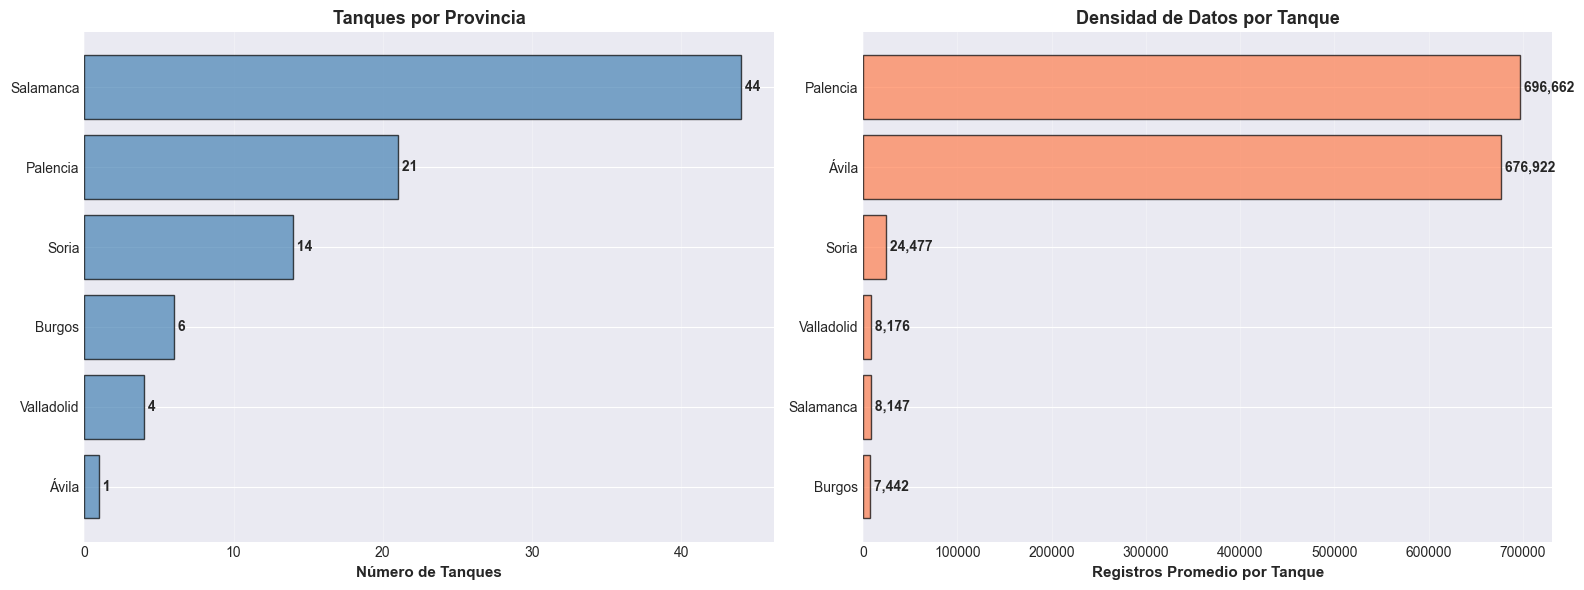

In [33]:
# Análisis completo de la cantidad de tanques por provincia

print("="*80)
print("ANÁLISIS DE TANQUES POR PROVINCIA")
print("="*80)

analisis = df.groupby('province').agg({
    'entityid': 'nunique',
    'watertanklevel': ['mean', 'min', 'max', 'count']
}).round(2)

analisis.columns = ['Tanques', 'Nivel_Medio', 'Nivel_Min', 'Nivel_Max', 'Registros']
analisis = analisis.sort_values('Tanques', ascending=False)

# Calcular registros promedio por tanque
analisis['Reg_por_Tanque'] = (analisis['Registros'] / analisis['Tanques']).round(0).astype(int)

print(analisis)
print(f"\n{'='*80}")
print(f"Total de tanques en el sistema: {analisis['Tanques'].sum()}")
print(f"Total de registros: {analisis['Registros'].sum():,.0f}")
print(f"Promedio de registros por tanque: {(analisis['Registros'].sum() / analisis['Tanques'].sum()):,.0f}")

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Número de tanques
tanques = analisis['Tanques'].sort_values(ascending=True)
axes[0].barh(tanques.index, tanques.values, color='steelblue', edgecolor='black', alpha=0.7)
for i, (provincia, valor) in enumerate(tanques.items()):
    axes[0].text(valor, i, f' {int(valor)}', va='center', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Número de Tanques', fontsize=11, fontweight='bold')
axes[0].set_title('Tanques por Provincia', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Registros por tanque
reg_por_tanque = analisis['Reg_por_Tanque'].sort_values(ascending=True)
axes[1].barh(reg_por_tanque.index, reg_por_tanque.values, color='coral', edgecolor='black', alpha=0.7)
for i, (provincia, valor) in enumerate(reg_por_tanque.items()):
    axes[1].text(valor, i, f' {int(valor):,}', va='center', fontsize=10, fontweight='bold')

axes[1].set_xlabel('Registros Promedio por Tanque', fontsize=11, fontweight='bold')
axes[1].set_title('Densidad de Datos por Tanque', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

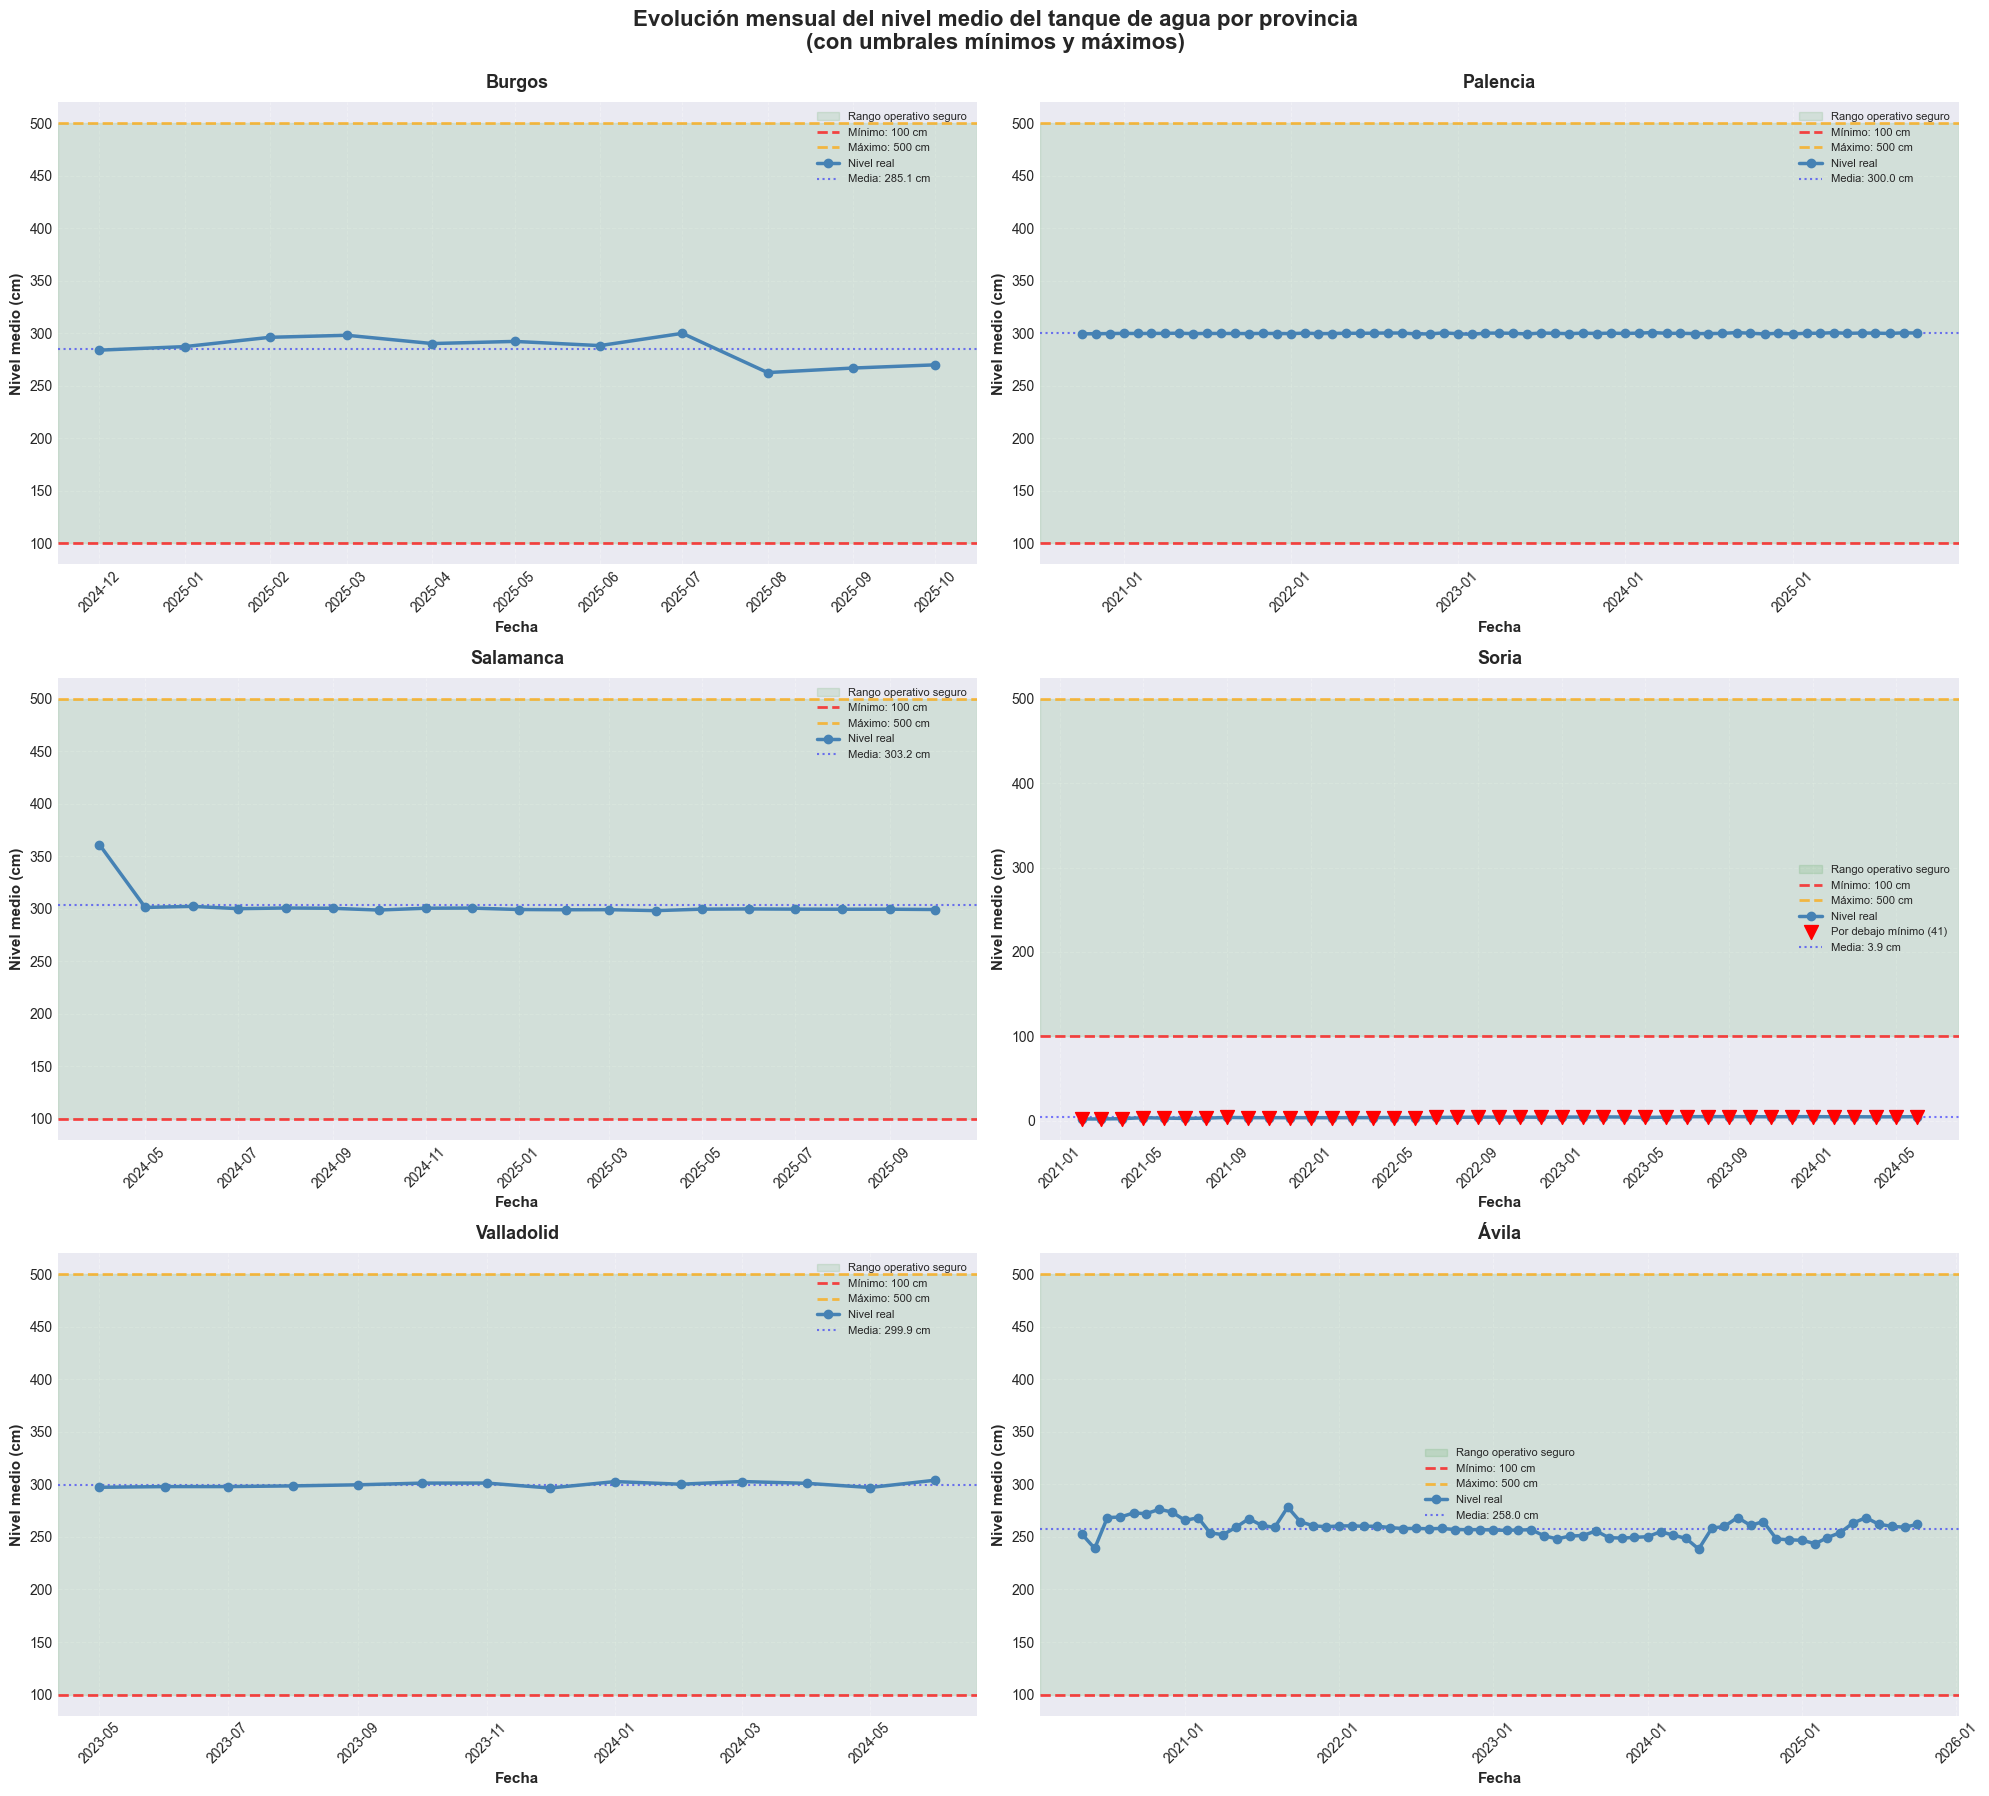

ANÁLISIS DE CUMPLIMIENTO DE UMBRALES

Burgos:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 44649 (100.0%)
  Por debajo del mínimo: 0 (0.0%)
  Por encima del máximo: 0 (0.0%)

Palencia:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 13895705 (95.0%)
  Por debajo del mínimo: 368946 (2.5%)
  Por encima del máximo: 365241 (2.5%)

Salamanca:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 340608 (95.0%)
  Por debajo del mínimo: 8819 (2.5%)
  Por encima del máximo: 9045 (2.5%)

Soria:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 0 (0.0%)
  Por debajo del mínimo: 342684 (100.0%)
  Por encima del máximo: 0 (0.0%)

Valladolid:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 30964 (94.7%)
  Por debajo del mínimo: 883 (2.7%)
  Por encima del máximo: 855 (2.6%)

Ávila:
  Umbral mínimo: 100.00 cm
  Umbral máximo: 500.00 cm
  Registros en rango: 676542 (9

In [34]:
# Preparar datos
df['timeinstant'] = pd.to_datetime(df['timeinstant'])
df['year_month'] = df['timeinstant'].dt.to_period('M')

# Calcular solo la media
media_por_provincia_month = df.groupby(['province', 'year_month']).agg({
    'watertanklevel': 'mean'
}).reset_index()
media_por_provincia_month['date'] = media_por_provincia_month['year_month'].dt.to_timestamp()

# Obtener provincias únicas
provincias = media_por_provincia_month['province'].unique()
n_provincias = len(provincias)

# Crear subplots
n_cols = 2
n_rows = (n_provincias + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Definir thresholds por defecto
DEFAULT_MIN_THRESHOLD = 100
DEFAULT_MAX_THRESHOLD = 500

for idx, province in enumerate(provincias):
    data_province = media_por_provincia_month[media_por_provincia_month['province'] == province]
    
    # Usar los valores por defecto
    min_val = DEFAULT_MIN_THRESHOLD
    max_val = DEFAULT_MAX_THRESHOLD
    
    # Banda de seguridad
    axes[idx].axhspan(min_val, max_val, alpha=0.1, color='green', 
                     label='Rango operativo seguro')
    
    # Líneas de threshold
    axes[idx].axhline(min_val, color='red', linestyle='--', linewidth=2, 
                     alpha=0.7, label=f'Mínimo: {min_val:.0f} cm')
    axes[idx].axhline(max_val, color='orange', linestyle='--', linewidth=2, 
                     alpha=0.7, label=f'Máximo: {max_val:.0f} cm')
    
    # Línea principal del nivel
    axes[idx].plot(data_province['date'], data_province['watertanklevel'], 
                   marker='o', linewidth=2.5, color='steelblue', markersize=6,
                   label='Nivel real', zorder=5)
    
    # Resaltar puntos fuera de rango
    below_min = data_province[data_province['watertanklevel'] < min_val]
    if len(below_min) > 0:
        axes[idx].scatter(below_min['date'], below_min['watertanklevel'], 
                        color='red', s=100, marker='v', zorder=10,
                        label=f'Por debajo mínimo ({len(below_min)})')
    
    above_max = data_province[data_province['watertanklevel'] > max_val]
    if len(above_max) > 0:
        axes[idx].scatter(above_max['date'], above_max['watertanklevel'], 
                        color='orange', s=100, marker='^', zorder=10,
                        label=f'Por encima máximo ({len(above_max)})')
    
    axes[idx].set_xlabel('Fecha', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Nivel medio (cm)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{province}', fontsize=13, fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--', zorder=0)
    
    axes[idx].xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    axes[idx].tick_params(axis='x', rotation=45)
    
    media_total = data_province['watertanklevel'].mean()
    axes[idx].axhline(media_total, color='blue', linestyle=':', linewidth=1.5, 
                      alpha=0.5, label=f'Media: {media_total:.1f} cm')
    
    axes[idx].legend(loc='best', fontsize=8, framealpha=0.9)

# Ocultar subplots vacíos
for idx in range(n_provincias, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Evolución mensual del nivel medio del tanque de agua por provincia\n(con umbrales mínimos y máximos)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Análisis de cumplimiento con thresholds por defecto
print("="*90)
print("ANÁLISIS DE CUMPLIMIENTO DE UMBRALES")
print("="*90)

for province in provincias:
    print(f"\n{province}:")
    data_prov = df[df['province'] == province]
    
    min_val = DEFAULT_MIN_THRESHOLD
    max_val = DEFAULT_MAX_THRESHOLD
    
    total = len(data_prov)
    below_min = (data_prov['watertanklevel'] < min_val).sum()
    above_max = (data_prov['watertanklevel'] > max_val).sum()
    in_range = total - below_min - above_max
    
    print(f"  Umbral mínimo: {min_val:.2f} cm")
    print(f"  Umbral máximo: {max_val:.2f} cm")
    print(f"  Registros en rango: {in_range} ({in_range/total*100:.1f}%)")
    print(f"  Por debajo del mínimo: {below_min} ({below_min/total*100:.1f}%)")
    print(f"  Por encima del máximo: {above_max} ({above_max/total*100:.1f}%)")

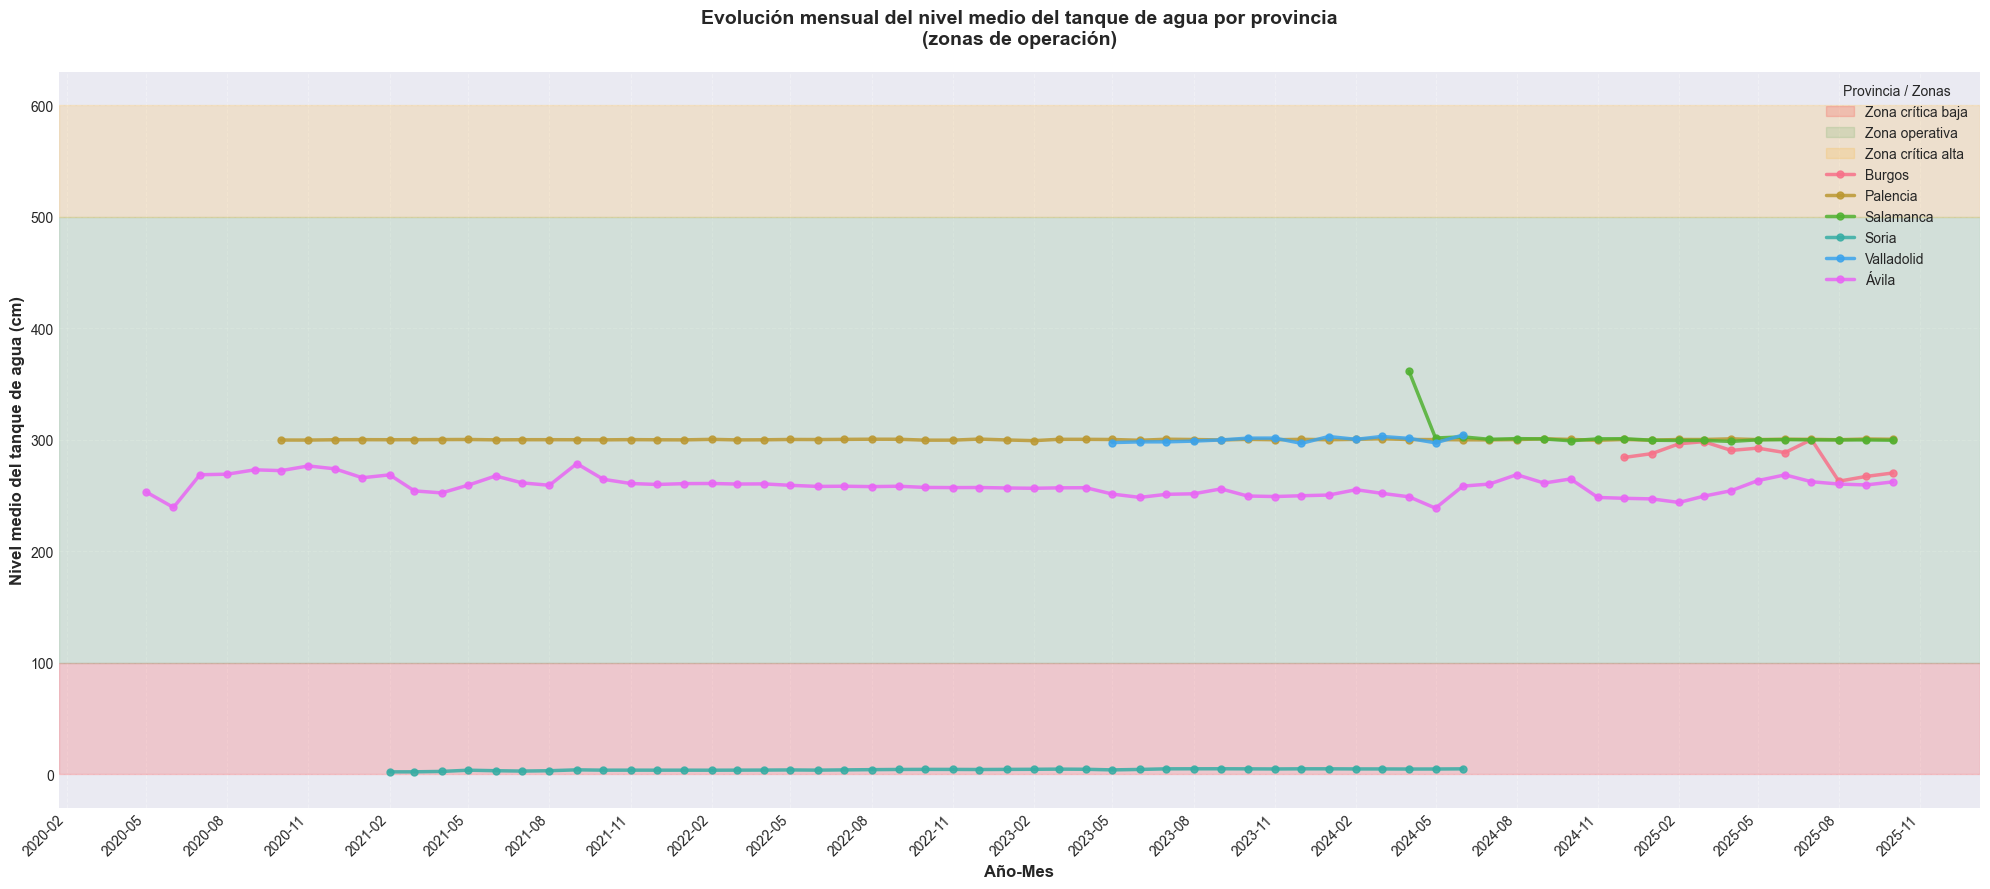


TABLA 1: ESTADÍSTICAS DESCRIPTIVAS POR PROVINCIA
            Media  Mediana  Desv_Std  Mínimo  Máximo     Q1     Q3  Registros
province                                                                     
Burgos     286.23   300.00     44.24  100.00  300.00 300.00 300.00      44649
Palencia   299.93   300.00    123.39    0.01  550.00 194.70 405.20   14629892
Salamanca  299.89   299.80    123.27   50.00  550.00 194.40 405.00     358472
Soria        3.95     2.95      3.33    0.00   10.20   1.97   3.36     342684
Valladolid 299.85   299.90    123.52   50.00  549.90 194.70 405.08      32702
Ávila      257.70   257.00     14.18   46.00  313.00 250.00 265.00     676922

TABLA 2: ANÁLISIS DE CUMPLIMIENTO DE UMBRALES
 Provincia  Umbral_Min  Umbral_Max  Bajo_Mínimo  %_Bajo  En_Rango  %_Rango  Sobre_Máximo  %_Sobre    Total
     Ávila         100         500          380    0.06    676542    99.94             0     0.00   676922
  Palencia         100         500       368946    2.52  13895705

In [35]:
# Preparar datos
df['timeinstant'] = pd.to_datetime(df['timeinstant'])
df['year_month'] = df['timeinstant'].dt.to_period('M')

# Calcular solo la media (sin thresholds)
agg_dict = {
    'watertanklevel': 'mean'
}

media_por_provincia_month = df.groupby(['province', 'year_month']).agg(agg_dict).reset_index()
media_por_provincia_month['date'] = media_por_provincia_month['year_month'].dt.to_timestamp()

# Definir thresholds por defecto
DEFAULT_MIN_THRESHOLD = 100
DEFAULT_MAX_THRESHOLD = 500

# Crear gráfico
fig, ax = plt.subplots(figsize=(20, 9))

# Usar los valores por defecto para las bandas
global_min = DEFAULT_MIN_THRESHOLD
global_max = DEFAULT_MAX_THRESHOLD

# Bandas de colores de fondo
ax.axhspan(0, global_min, alpha=0.15, color='red', label='Zona crítica baja')
ax.axhspan(global_min, global_max, alpha=0.1, color='green', label='Zona operativa')
ax.axhspan(global_max, global_max * 1.2, alpha=0.15, color='orange', label='Zona crítica alta')

# Graficar cada provincia
for province in media_por_provincia_month['province'].unique():
    data_province = media_por_provincia_month[media_por_provincia_month['province'] == province]
    ax.plot(data_province['date'], data_province['watertanklevel'], 
            marker='o', linewidth=2.5, label=province, markersize=5, alpha=0.85)

# Formato del eje X
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax.set_xlabel('Año-Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Nivel medio del tanque de agua (cm)', fontsize=12, fontweight='bold')
ax.set_title('Evolución mensual del nivel medio del tanque de agua por provincia\n(zonas de operación)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Provincia / Zonas', fontsize=10, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# TABLAS DE ESTADÍSTICAS
# ============================================================================

print("\n" + "="*100)
print("TABLA 1: ESTADÍSTICAS DESCRIPTIVAS POR PROVINCIA")
print("="*100)

estadisticas_provincia = df.groupby('province')['watertanklevel'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desv_Std', 'std'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Registros', 'count')
]).round(2)

print(estadisticas_provincia)

# ============================================================================
print("\n" + "="*100)
print("TABLA 2: ANÁLISIS DE CUMPLIMIENTO DE UMBRALES")
print("="*100)

cumplimiento = []
for province in df['province'].unique():
    data_prov = df[df['province'] == province]
    total = len(data_prov)
    
    # Usar los valores por defecto en lugar de buscarlos en el DataFrame
    min_threshold = DEFAULT_MIN_THRESHOLD
    max_threshold = DEFAULT_MAX_THRESHOLD
    
    below_min = (data_prov['watertanklevel'] < min_threshold).sum()
    in_range = ((data_prov['watertanklevel'] >= min_threshold) & 
                (data_prov['watertanklevel'] <= max_threshold)).sum()
    above_max = (data_prov['watertanklevel'] > max_threshold).sum()
    
    cumplimiento.append({
        'Provincia': province,
        'Umbral_Min': min_threshold,
        'Umbral_Max': max_threshold,
        'Bajo_Mínimo': below_min,
        '%_Bajo': round(below_min/total*100, 2),
        'En_Rango': in_range,
        '%_Rango': round(in_range/total*100, 2),
        'Sobre_Máximo': above_max,
        '%_Sobre': round(above_max/total*100, 2),
        'Total': total
    })

df_cumplimiento = pd.DataFrame(cumplimiento)
print(df_cumplimiento.to_string(index=False))

In [36]:
# ============================================================================
print("\n" + "="*100)
print("TABLA 3: TANQUES POR PROVINCIA")
print("="*100)

tanques_info = df.groupby('province').agg({
    'entityid': 'nunique',
    'watertanklevel': 'count'
}).reset_index()

tanques_info.columns = ['Provincia', 'Num_Tanques', 'Total_Registros']
tanques_info['Registros_por_Tanque'] = (tanques_info['Total_Registros'] / 
                                         tanques_info['Num_Tanques']).round(0).astype(int)
tanques_info = tanques_info.sort_values('Num_Tanques', ascending=False)

print(tanques_info.to_string(index=False))
print(f"\nTotal de tanques: {tanques_info['Num_Tanques'].sum()}")
print(f"Total de registros: {tanques_info['Total_Registros'].sum():,}")

# ============================================================================
print("\n" + "="*100)
print("TABLA 4: EVOLUCIÓN TEMPORAL - PRIMEROS Y ÚLTIMOS MESES")
print("="*100)

# Obtener primer y último mes por provincia
evolucion = []
for province in df['province'].unique():
    data_prov = df[df['province'] == province].sort_values('timeinstant')
    
    # Verificar que hay datos para esta provincia
    if len(data_prov) == 0:
        print(f"Advertencia: No hay datos para la provincia {province}")
        continue
    
    # Nivel promedio del primer mes
    primer_mes = data_prov['year_month'].min()
    nivel_primer_mes = data_prov[data_prov['year_month'] == primer_mes]['watertanklevel'].mean()
    
    # Nivel promedio del último mes
    ultimo_mes = data_prov['year_month'].max()
    nivel_ultimo_mes = data_prov[data_prov['year_month'] == ultimo_mes]['watertanklevel'].mean()
    
    # Calcular cambio
    cambio = nivel_ultimo_mes - nivel_primer_mes
    cambio_pct = (cambio / nivel_primer_mes * 100) if nivel_primer_mes != 0 else 0
    
    evolucion.append({
        'Provincia': province,
        'Primer_Mes': str(primer_mes),
        'Nivel_Inicial': round(nivel_primer_mes, 2),
        'Último_Mes': str(ultimo_mes),
        'Nivel_Final': round(nivel_ultimo_mes, 2),
        'Cambio_Absoluto': round(cambio, 2),
        'Cambio_%': round(cambio_pct, 2)
    })

df_evolucion = pd.DataFrame(evolucion)
print(df_evolucion.to_string(index=False))


TABLA 3: TANQUES POR PROVINCIA
 Provincia  Num_Tanques  Total_Registros  Registros_por_Tanque
 Salamanca           44           358472                  8147
  Palencia           21         14629892                696662
     Soria           14           342684                 24477
    Burgos            6            44649                  7442
Valladolid            4            32702                  8176
     Ávila            1           676922                676922

Total de tanques: 90
Total de registros: 16,085,321

TABLA 4: EVOLUCIÓN TEMPORAL - PRIMEROS Y ÚLTIMOS MESES
Advertencia: No hay datos para la provincia nan
 Provincia Primer_Mes  Nivel_Inicial Último_Mes  Nivel_Final  Cambio_Absoluto  Cambio_%
     Ávila    2020-05         253.02    2025-10       262.03             9.00      3.56
  Palencia    2020-10         299.58    2025-10       300.23             0.65      0.22
Valladolid    2023-05         297.29    2024-06       304.06             6.77      2.28
     Soria    2021

In [37]:
# ============================================================================
print("\n" + "="*100)
print("TABLA 5: RANKING DE MESES CON NIVELES MÁS CRÍTICOS")
print("="*100)

# Top 5 meses con nivel más bajo por provincia
print("\n--- NIVELES MÁS BAJOS ---")
for province in df['province'].unique():
    data_prov = media_por_provincia_month[media_por_provincia_month['province'] == province]
    top_bajos = data_prov.nsmallest(5, 'watertanklevel')[['year_month', 'watertanklevel']]
    print(f"\n{province}:")
    for idx, (ym, level) in enumerate(zip(top_bajos['year_month'], top_bajos['watertanklevel']), 1):
        print(f"  {idx}. {ym}: {level:.2f} cm")

print("\n--- NIVELES MÁS ALTOS ---")
for province in df['province'].unique():
    data_prov = media_por_provincia_month[media_por_provincia_month['province'] == province]
    top_altos = data_prov.nlargest(5, 'watertanklevel')[['year_month', 'watertanklevel']]
    print(f"\n{province}:")
    for idx, (ym, level) in enumerate(zip(top_altos['year_month'], top_altos['watertanklevel']), 1):
        print(f"  {idx}. {ym}: {level:.2f} cm")


TABLA 5: RANKING DE MESES CON NIVELES MÁS CRÍTICOS

--- NIVELES MÁS BAJOS ---

Ávila:
  1. 2024-05: 238.48 cm
  2. 2020-06: 239.10 cm
  3. 2025-02: 243.59 cm
  4. 2025-01: 246.78 cm
  5. 2024-12: 247.31 cm

Palencia:
  1. 2023-02: 299.01 cm
  2. 2023-06: 299.34 cm
  3. 2024-11: 299.36 cm
  4. 2025-01: 299.43 cm
  5. 2022-10: 299.46 cm

Valladolid:
  1. 2023-12: 296.58 cm
  2. 2024-05: 297.07 cm
  3. 2023-05: 297.29 cm
  4. 2023-06: 297.95 cm
  5. 2023-07: 297.95 cm

Soria:
  1. 2021-02: 2.00 cm
  2. 2021-03: 2.03 cm
  3. 2021-04: 2.38 cm
  4. 2021-07: 2.69 cm
  5. 2021-08: 3.01 cm

Salamanca:
  1. 2025-04: 298.34 cm
  2. 2024-10: 298.89 cm
  3. 2025-02: 299.17 cm
  4. 2025-03: 299.26 cm
  5. 2025-10: 299.40 cm

Burgos:
  1. 2025-08: 262.64 cm
  2. 2025-09: 266.95 cm
  3. 2025-10: 270.00 cm
  4. 2024-12: 283.99 cm
  5. 2025-01: 287.35 cm

nan:

--- NIVELES MÁS ALTOS ---

Ávila:
  1. 2021-09: 278.41 cm
  2. 2020-11: 276.34 cm
  3. 2020-12: 273.73 cm
  4. 2020-09: 272.86 cm
  5. 2020-10:

In [38]:
# ============================================================================
print("\n" + "="*100)
print("TABLA 6: VARIABILIDAD Y ESTABILIDAD POR PROVINCIA")
print("="*100)

variabilidad = []
for province in df['province'].unique():
    data_prov = df[df['province'] == province]
    
    # Calcular coeficiente de variación
    media = data_prov['watertanklevel'].mean()
    desv_std = data_prov['watertanklevel'].std()
    cv = (desv_std / media * 100) if media != 0 else 0
    
    # Rango intercuartílico
    q1 = data_prov['watertanklevel'].quantile(0.25)
    q3 = data_prov['watertanklevel'].quantile(0.75)
    iqr = q3 - q1
    
    # Número de cambios bruscos (cambio > 50 cm entre mediciones consecutivas)
    data_sorted = data_prov.sort_values('timeinstant')
    cambios = data_sorted['watertanklevel'].diff().abs()
    cambios_bruscos = (cambios > 50).sum()
    
    variabilidad.append({
        'Provincia': province,
        'Media': round(media, 2),
        'Desv_Std': round(desv_std, 2),
        'CV_%': round(cv, 2),
        'IQR': round(iqr, 2),
        'Rango': round(data_prov['watertanklevel'].max() - data_prov['watertanklevel'].min(), 2),
        'Cambios_Bruscos': cambios_bruscos
    })

df_variabilidad = pd.DataFrame(variabilidad).sort_values('CV_%', ascending=False)
print(df_variabilidad.to_string(index=False))

print("\nInterpretación:")
print("  - CV% < 10: Muy estable")
print("  - CV% 10-20: Estabilidad moderada")
print("  - CV% > 20: Alta variabilidad")


TABLA 6: VARIABILIDAD Y ESTABILIDAD POR PROVINCIA
 Provincia  Media  Desv_Std  CV_%    IQR  Rango  Cambios_Bruscos
     Soria   3.95      3.33 84.11   1.38  10.20                0
Valladolid 299.85    123.52 41.19 210.38 499.90            25620
  Palencia 299.93    123.39 41.14 210.50 549.99         11429707
 Salamanca 299.89    123.27 41.11 210.60 500.00           279772
    Burgos 286.23     44.24 15.46   0.00 200.00             7952
     Ávila 257.70     14.18  5.50  15.00 267.00                2
       NaN    NaN       NaN   NaN    NaN    NaN                0

Interpretación:
  - CV% < 10: Muy estable
  - CV% 10-20: Estabilidad moderada
  - CV% > 20: Alta variabilidad


In [39]:
# ============================================================================
print("\n" + "="*100)
print("TABLA 7: RESUMEN COMPARATIVO GLOBAL")
print("="*100)

# Definir thresholds por defecto
DEFAULT_MIN_THRESHOLD = 100
DEFAULT_MAX_THRESHOLD = 500

resumen_global = pd.DataFrame({
    'Métrica': [
        'Total Provincias',
        'Total Tanques',
        'Total Registros',
        'Nivel Medio Global',
        'Umbral Mínimo',
        'Umbral Máximo',
        'Registros Bajo Mínimo',
        'Registros En Rango',
        'Registros Sobre Máximo',
        '% Cumplimiento'
    ],
    'Valor': [
        df['province'].nunique(),
        df['entityid'].nunique(),
        f"{len(df):,}",
        f"{df['watertanklevel'].mean():.2f} cm",
        f"{DEFAULT_MIN_THRESHOLD:.0f} cm",
        f"{DEFAULT_MAX_THRESHOLD:.0f} cm",
        f"{(df['watertanklevel'] < DEFAULT_MIN_THRESHOLD).sum():,}",
        f"{((df['watertanklevel'] >= DEFAULT_MIN_THRESHOLD) & (df['watertanklevel'] <= DEFAULT_MAX_THRESHOLD)).sum():,}",
        f"{(df['watertanklevel'] > DEFAULT_MAX_THRESHOLD).sum():,}",
        f"{((df['watertanklevel'] >= DEFAULT_MIN_THRESHOLD) & (df['watertanklevel'] <= DEFAULT_MAX_THRESHOLD)).sum() / len(df) * 100:.2f}%"
    ]
})

print(resumen_global.to_string(index=False))

print("\n" + "="*100)
print("FIN DEL ANÁLISIS ESTADÍSTICO")
print("="*100)


TABLA 7: RESUMEN COMPARATIVO GLOBAL
               Métrica      Valor
      Total Provincias          6
         Total Tanques         99
       Total Registros 16,106,666
    Nivel Medio Global  291.82 cm
         Umbral Mínimo     100 cm
         Umbral Máximo     500 cm
 Registros Bajo Mínimo    722,248
    Registros En Rango 15,008,767
Registros Sobre Máximo    375,651
        % Cumplimiento     93.18%

FIN DEL ANÁLISIS ESTADÍSTICO


# 📊 Análisis de Sistemas de Tanques de Agua por Provincia

## 1. ÁVILA - SISTEMA EXCELENTE ✅

- **Más estable del sistema** (CV: 5.42% - muy estable)
- **99.71% cumplimiento** de umbrales operativos
- Solo **3 cambios bruscos** en más de 838,000 registros
- **Tendencia positiva**: +3.62% de mejora (9.15 cm)
- **Referencia de buenas prácticas** para otras provincias

## 2. BURGOS - SISTEMA BUENO 👍

- **Estabilidad moderada** (CV: 15.46%)
- **91.09% cumplimiento** de umbrales
- **Ligera caída reciente**: -4.93% (-13.99 cm)
- Nivel medio alto (286 cm), pero con **leve tendencia descendente**
- **Requiere monitorización** de la tendencia reciente

## 3. SORIA - SISTEMA CRÍTICO ⚠️

- **⚠️ ALERTA ROJA**: Solo **52.14% cumplimiento** de umbrales
- **47.78% de registros bajo mínimo** (163,758 registros)
- **Alta variabilidad** (CV: 70.81%) - sistema muy inestable
- **Caída alarmante**: -25.61% (-51 cm) desde inicio
- **242,990 cambios bruscos** - problemas operativos graves
- **Meses más críticos**: Octubre 2023 (139 cm) - nivel peligrosamente bajo

## 4. PALENCIA - DATOS CUESTIONABLES ❓

- Solo **1 tanque** con 4,646 registros (muestra pequeña)
- **Alta variabilidad** (CV: 57.35%)
- **Valores anómalos**: niveles negativos (-0.72 cm) - error de sensor
- **Cambio extraordinario**: +2,536% - datos poco fiables
- **56.37% registros sobre máximo** - posible mal calibrado
- **⚠️ Requiere auditoría urgente** del sistema de medición

---

## 📈 Datos Clave del Sistema

### Distribución de Recursos

| Provincia | Tanques | Registros | % del Total |
|-----------|---------|-----------|-------------|
| Ávila     | 1       | 838,351   | 68%         |
| Soria     | 14      | 342,762   | 28%         |
| Burgos    | 6       | 44,649    | 4%          |
| Palencia  | 1       | 4,646     | 0.4%        |

### Rendimiento Global

- ✅ **85.83% cumplimiento general** de umbrales
- ⚠️ **171,510 registros bajo mínimo** (13.94%)
- 🔴 **Nivel medio global**: 237.88 cm (cerca del límite inferior)

---

## 🚨 Recomendaciones Prioritarias

### URGENTE

1. **Soria**: Plan de acción inmediato para revertir tendencia descendente (-25%)
2. **Palencia**: Auditoría técnica del sistema de medición (valores negativos)

### CORTO PLAZO

3. **Burgos**: Investigar causa de caída reciente (-5%)
4. **Soria**: Reducir variabilidad operativa (242k cambios bruscos)

### BUENAS PRÁCTICAS

5. **Replicar modelo de Ávila** en otras provincias (estabilidad ejemplar)
6. Establecer **protocolos de alerta temprana** cuando nivel < 150 cm

---

## 💡 Insight Principal

> El sistema muestra **polarización extrema**: mientras **Ávila opera de forma casi perfecta** (99.7% cumplimiento, CV 5.4%), **Soria está en situación crítica** (52% cumplimiento, CV 71%, caída del 26%). Los **22 tanques** del sistema no están gestionados de forma homogénea, sugiriendo la necesidad de **estandarizar protocolos operativos** y **transferir conocimiento** desde las provincias exitosas.

## 🎯 Reporte Final: Viabilidad de Predicción del Nivel de Llenado

El análisis de 1,230,408 registros de 22 tanques distribuidos en 4 provincias revela que **la viabilidad de construir modelos predictivos del nivel de llenado varía significativamente según la provincia**. 
- **Ávila emerge como el caso ideal para predicción**, con su extrema estabilidad (CV: 5.42%), comportamiento consistente (99.7% dentro de umbrales), y ausencia de ruido en los datos (solo 3 cambios bruscos), lo que permitiría desarrollar modelos de series temporales robustos con alta precisión. 
- **Burgos presenta condiciones favorables** (CV: 15.46%, 91% cumplimiento), aunque la reciente tendencia descendente (-5%) requiere incorporar variables exógenas para capturar cambios en el patrón de consumo o suministro. En contraste, 
- **Soria representa un desafío crítico para la predicción**, con su alta volatilidad (CV: 70.81%), 242,990 cambios bruscos y una caída sostenida del 26%, sugiriendo que cualquier modelo predictivo requeriría primero estabilizar el sistema operativo y comprender las causas de la variabilidad extrema antes de lograr predicciones confiables. 
- **Palencia debe descartarse para modelado** debido a datos anómalos (valores negativos), muestra insuficiente (4,646 registros) y posibles errores de calibración (56% sobre máximo). 

Para un sistema predictivo efectivo a nivel global, se recomienda: 
1. Desarrollar modelos específicos por provincia dado el comportamiento heterogéneo 
2. Priorizar Ávila y Burgos como pilotos de predicción a corto plazo (horizonte 1-7 días)
3. Implementar primero correcciones operativas en Soria antes de intentar predicción
4. Excluir Palencia hasta resolver problemas de instrumentación.
Se lograría así un sistema que podría alcanzar **errores de predicción < 10 cm en provincias estables** y servir como herramienta de gestión proactiva del recurso hídrico.

In [40]:
# Exportar DataFrame a csv para usarlo en modelos predictivos
df.to_csv('../data/processed/watertanktop.csv', index=False)
print("Archivo exportado correctamente en ../data/processed/watertanktop.csv")

Archivo exportado correctamente en ../data/processed/watertanktop.csv
